# Partea I — Analiza exploratorie privind rezultatele din rulările interogărilor

In [12]:
getwd()

[1] "C:/Users/savas/TCP-DS/notebooks"

In [17]:
#install.packages(c("gtsummary", "tinytable", "corrplot"))

In [1]:
library(tidyverse)
library(janitor)
library(scales)
library(knitr)
library(gtsummary)
library(tinytable)
library(corrplot)

── Attaching core tidyverse packages ──────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
"package 'janitor' was built under R version 4.4.3"

Attaching package: 'janitor'


The following objects are masked from 'package:stats':

    chisq.test, fisher.test



Attaching package: 'scales'


The following object is masked from 'package:purrr':

    discard


The following object is masked from 'package:readr':

    col_factor


Warning message:
"package 'gtsummary' w

Setare context
- fisier cu rezultate din rulări
- definiere foldere output - figuri și tabele

In [2]:
base_dir <- ".."
input_file <- file.path(base_dir, "citus_outputs", "results_master.csv")

tables_dir <- file.path(base_dir, "citus_outputs", "tables")
figures_dir <- file.path(base_dir, "citus_outputs", "figures")

In [3]:
results_master <- read_csv(input_file) %>%
  clean_names()

glimpse(results_master)

Rows: 3750 Columns: 15
── Column specification ────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (8): scenario, strategy, query_id, status, error_category, response_code...
dbl (6): sf, workers, query_no, elapsed_ms, elapsed_sec, restart_from
lgl (1): success

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Rows: 3,750
Columns: 15
$ scenario         <chr> "SF10_N0", "SF10_N0", "SF10_N0", "SF10_N0", "SF10_N0"…
$ sf               <dbl> 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 1…
$ workers          <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,…
$ strategy         <chr> "baseline", "baseline", "baseline", "baseline", "base…
$ query_no         <dbl> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16…
$ query_id         <chr> "Q001", "Q002", "Q003", "Q004", "Q005", "Q006", "Q007…
$ status           <chr> "SUCCESS", "SUCCESS", "SUCCESS", "SUCCESS", "SUCCESS"…
$ error_category   <chr> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, N…
$ elapsed_ms       <dbl> 14165, 6954, 11010, 12679, 29054, 114241, 1416, 36293…
$ elapsed_sec      <dbl> 14.165, 6.954, 11.010, 12.679, 29.054, 114.241, 1.416…
$ success          <lgl> TRUE, TRUE, TRUE, TRUE, TRUE, TRUE, TRUE, TRUE, TRUE,…
$ response_code    <chr> "200", "200", "200", "200", "200", "200", "200", "200…
$ response_messa

Dataframe-ul pentru rezultate conține 3.750 de observații și 15 coloane -> 15 scenarii experimentale × 250 de interogări SQL.

Variabilele `scenario`, `sf`, `workers` și `strategy` descriu configurația experimentală, `query_id` și `query_no` identifică interogarea executată, iar `status`, `success`, `elapsed_ms` și `elapsed_sec` descriu rezultatul execuției.
Coloanele `response_code`, `response_message`, `error_category`, `source_file` și `restart_from` păstrează trasabilitatea execuțiilor și a procesului de consolidare.


In [21]:
dataset_check <- results_master %>%
  summarise(
    total_observatii = n(),
    total_scenarii = n_distinct(scenario),
    total_query_ids = n_distinct(query_id),
    total_scale_factors = n_distinct(sf),
    total_strategy = n_distinct(strategy)
  )

dataset_check

total_observatii,total_scenarii,total_query_ids,total_scale_factors,total_strategy
<int>,<int>,<int>,<int>,<int>
3750,15,250,3,3


Verificare integritate dataset final: 3.750 de observații, 15 scenarii experimentale, 250 de interogări distincte și 3 sf.
Aceste valori corespund designului experimental, în care fiecare interogare a fost rulată o singură dată în fiecare scenariu.

Variabila `strategy` are trei niveluri: `baseline`, `D1` și `D2`, unde `baseline` nu reprezintă o strategie de distribuire, ci scenariul PostgreSQL mononod folosit ca punct de referință pentru comparațiile cu scenariile distribuite.

scenario_check <- results_master %>%
  count(scenario, sf, workers, strategy, name = "n_rows") %>%
  mutate(
    expected_rows = 250,
    is_complete = n_rows == expected_rows
  ) %>%
  arrange(sf, workers, strategy)

scenario_check

Se confirmă completitudinea scenariilor testate: 250 de interogări rulate în fiecare dintre acestea.

In [22]:
results_master %>%
  distinct(status)

status
<chr>
SUCCESS
CITUS_ARCH_ERROR
TIMEOUT_3600
SERVER_CRASH


Datasetul conține patru statusuri finale: `SUCCESS`, `CITUS_ARCH_ERROR`, `TIMEOUT_3600` și `SERVER_CRASH`.

In [23]:
missing_summary <- results_master %>%
  summarise(across(everything(), ~ sum(is.na(.)))) %>%
  pivot_longer(everything(), names_to = "variabila", values_to = "n_missing") %>%
  mutate(percent_missing = round(n_missing / nrow(results_master) * 100, 2)) %>%
  arrange(desc(n_missing))

missing_summary

variabila,n_missing,percent_missing
<chr>,<int>,<dbl>
error_category,3371,89.89
scenario,0,0.00
sf,0,0.00
workers,0,0.00
strategy,0,0.00
query_no,0,0.00
query_id,0,0.00
status,0,0.00
elapsed_ms,0,0.00


In [9]:
results_master %>%
  mutate(error_category_lipsa = is.na(error_category)) %>%
  count(status, error_category_lipsa, name = "n_observatii") %>%
  pivot_wider(
    names_from = error_category_lipsa,
    values_from = n_observatii,
    values_fill = 0,
    names_prefix = "error_NA_"
  )

status,error_NA_FALSE,error_NA_TRUE
<chr>,<int>,<int>
CITUS_ARCH_ERROR,312,0
SERVER_CRASH,18,0
SUCCESS,0,3371
TIMEOUT_3600,49,0


Verificarea valorilor lipsă arată că singura coloană cu valori `NA` este `error_category`, iar acestea apar exclusiv pentru execuțiile finalizate cu succes. 
Astfel, execuțiile reușite nu au asociată o categorie de eroare.

In [25]:
results_master %>%
  summarise(
    n_total = n(),
    n_elapsed_negativ = sum(elapsed_ms < 0, na.rm = TRUE),
    n_elapsed_zero    = sum(elapsed_ms == 0, na.rm = TRUE),
    n_elapsed_na      = sum(is.na(elapsed_ms))
  )

n_total,n_elapsed_negativ,n_elapsed_zero,n_elapsed_na
<int>,<int>,<int>,<int>
3750,0,0,0


Verificare timpi: negativi, zero sau lipsă - nu e cazul.

In [11]:
results_master %>%
  summarise(
    success_true_status_diferit = sum(success == TRUE  & status != "SUCCESS"),
    success_false_status_succes = sum(success == FALSE & status == "SUCCESS")
  )

success_true_status_diferit,success_false_status_succes
<int>,<int>
0,0


In [12]:
duplicate_check <- results_master %>%
  count(scenario, query_id, name = "n_aparitii") %>%
  filter(n_aparitii > 1)

duplicate_check

scenario,query_id,n_aparitii
<chr>,<chr>,<int>


Fiecare interogare are o singura rulare într-un scenariu. Nu există duplicate.

In [43]:
scenario_order <- results_master %>%
  distinct(scenario, sf, workers, strategy) %>%
  mutate(
    strategy_order = case_when(
      strategy == "baseline" ~ 0,
      strategy == "D1" ~ 1,
      strategy == "D2" ~ 2,
      TRUE ~ 99
    )
  ) %>%
  arrange(sf, workers, strategy_order) %>%
  pull(scenario)

status_order <- c("SUCCESS", "CITUS_ARCH_ERROR", "TIMEOUT_3600", "SERVER_CRASH")

In [44]:
status_colors <- c(
  "SUCCESS" = "#00BFC4",
  "CITUS_ARCH_ERROR" = "#F8766D",
  "TIMEOUT_3600" = "#C77CFF",
  "SERVER_CRASH" = "#7CAE00"
)

## Distribuții univariate ale variabilelor categoriale privind execuția

Înainte de analiza comparativă propriu-zisă, este utilă verificarea distribuției principalelor variabile categoriale care descriu execuțiile experimentale. Aceste variabile sunt `sf`, `workers`, `strategy` și `status`.

Variabilele `sf`, `workers` și `strategy` descriu configurația experimentală în care a fost rulată fiecare interogare, în timp ce `status` descrie rezultatul execuției. Analiza distribuției acestora permite verificarea echilibrului designului experimental și oferă o primă imagine asupra ponderii execuțiilor reușite și nereușite.

In [31]:
exec_categorical_dist <- bind_rows(
  results_master %>% count(value = as.character(sf), name = "n") %>%
    mutate(variable = "sf"),
  results_master %>% count(value = as.character(workers), name = "n") %>%
    mutate(variable = "workers"),
  results_master %>% count(value = strategy, name = "n") %>%
    mutate(variable = "strategy"),
  results_master %>% count(value = status, name = "n") %>%
    mutate(variable = "status")
) %>%
  group_by(variable) %>%
  mutate(percent = round(n / sum(n) * 100, 1)) %>%
  ungroup() %>%
  select(variable, value, n, percent) %>%
  arrange(variable, desc(n))

exec_categorical_dist

variable,value,n,percent
<chr>,<chr>,<int>,<dbl>
sf,10,1250,33.3
sf,100,1250,33.3
sf,50,1250,33.3
status,SUCCESS,3371,89.9
status,CITUS_ARCH_ERROR,312,8.3
status,TIMEOUT_3600,49,1.3
status,SERVER_CRASH,18,0.5
strategy,D1,1500,40.0
strategy,D2,1500,40.0


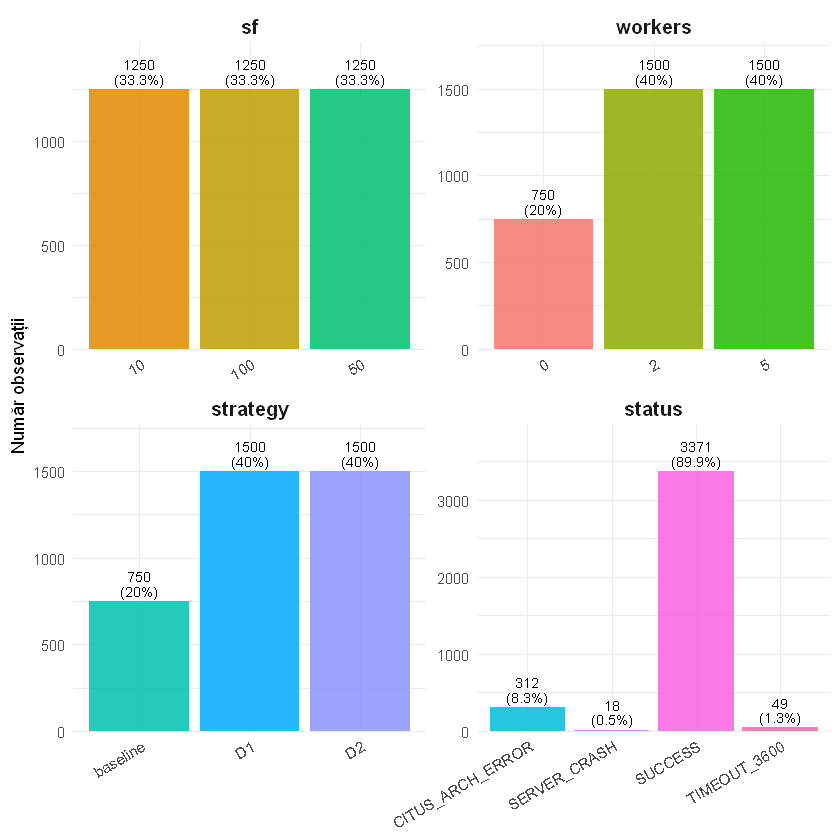

In [32]:
# === Figură: distribuții univariate variabile de execuție ===
p_exec_categorical <- exec_categorical_dist %>%
  mutate(
    variable = factor(variable, levels = c("sf", "workers", "strategy", "status"))
  ) %>%
  ggplot(aes(x = value, y = n, fill = value)) +
    geom_col(alpha = 0.85) +
    geom_text(
      aes(label = paste0(n, "\n(", percent, "%)")),
      vjust = -0.2, size = 3, lineheight = 0.85
    ) +
    facet_wrap(~ variable, scales = "free", nrow = 2) +
    scale_y_continuous(expand = expansion(mult = c(0, 0.18))) +
    labs(x = NULL, y = "Număr observații") +
    theme_minimal(base_size = 11) +
    theme(
      legend.position = "none",
      strip.text = element_text(face = "bold", size = 12),
      axis.text.x = element_text(angle = 30, hjust = 1)
    )

p_exec_categorical

Distribuțiile univariate confirmă structura echilibrată a designului experimental pentru sf: fiecare scale factor are 1.250 de observații, adică 33,3% din total. Pentru workers și strategy, distribuția reflectă faptul că scenariul baseline apare o singură dată per scale factor, în timp ce scenariile distribuite sunt definite pentru două strategii și două configurații de workeri.

Astfel, baseline și workers = 0 reprezintă 20,0% din observații, iar scenariile distribuite D1/D2 și N2/N5 reprezintă câte 40,0%. Distribuția statusurilor arată că majoritatea execuțiilor sunt SUCCESS (89,9%), urmate de CITUS_ARCH_ERROR (8,3%), TIMEOUT_3600 (1,3%) și SERVER_CRASH (0,5%)

In [10]:
status_global <- results_master %>%
  count(status, name = "n_queries") %>%
  mutate(
    total_queries = sum(n_queries),
    pct_queries = n_queries / total_queries,
    status = factor(status, levels = status_order)
  ) %>%
  arrange(status)

write_csv(
  status_global,
  file.path(tables_dir, "summary_status_global.csv")
)

status_global

status,n_queries,total_queries,pct_queries
<fct>,<int>,<int>,<dbl>
SUCCESS,3371,3750,0.89893333
CITUS_ARCH_ERROR,312,3750,0.08320000
TIMEOUT_3600,49,3750,0.01306667
SERVER_CRASH,18,3750,0.00480000


Distribuția globală a statusurilor arată că 3.371 din cele 3.750 de execuții au fost finalizate cu succes, ceea ce corespunde unei rate globale de succes de aproximativ 89,9%. Restul execuțiilor sunt reprezentate de erori arhitecturale Citus, timeout-uri și cazuri de tip `SERVER_CRASH`.

Cea mai frecventă categorie de eșec este `CITUS_ARCH_ERROR`, cu 312 execuții, adică 8,3% din total. Această pondere indică faptul că, pentru workload-ul analizat, executabilitatea în scenarii distribuite nu depinde doar de volumul datelor sau de timpul de procesare, ci și de compatibilitatea interogărilor cu mecanismele de execuție distribuită ale Citus.

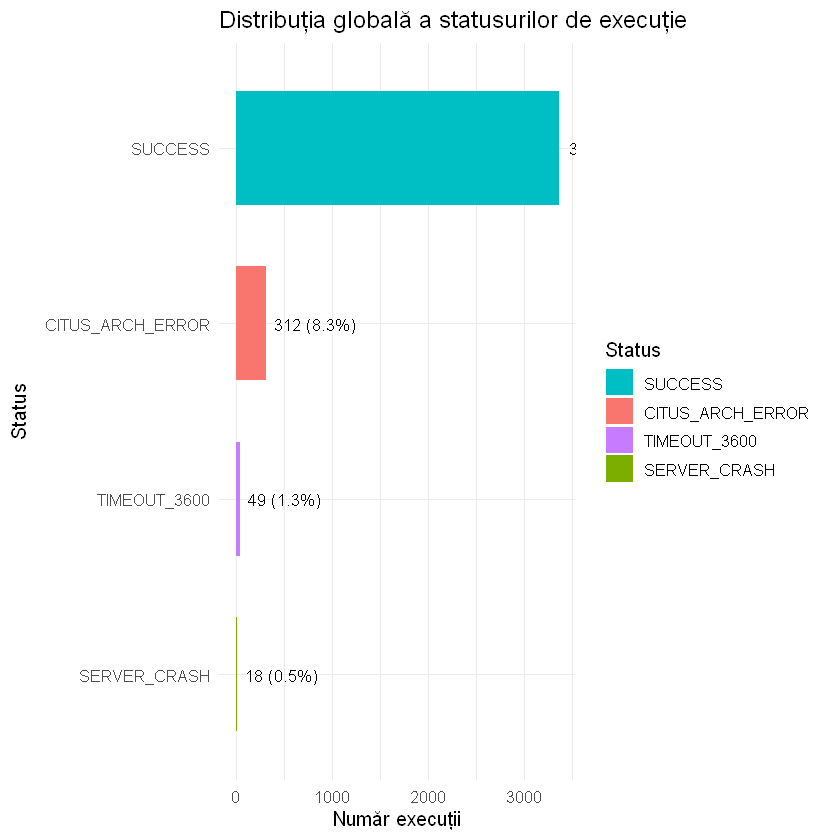

In [11]:
p_status_global <- status_global %>%
  ggplot(aes(x = reorder(status, n_queries), y = n_queries, fill = status)) +
  geom_col(width = 0.65) +
  geom_text(
    aes(label = paste0(n_queries, " (", round(pct_queries * 100, 1), "%)")),
    hjust = -0.1,
    size = 3.5
  ) +
  coord_flip() +
  scale_fill_manual(values = status_colors) +
  labs(
    title = "Distribuția globală a statusurilor de execuție",
    x = "Status",
    y = "Număr execuții",
    fill = "Status"
  ) +
  theme_minimal(base_size = 12)

p_status_global

ggsave(
  filename = file.path(figures_dir, "plot_status_global.png"),
  plot = p_status_global,
  width = 9,
  height = 5,
  dpi = 300
)

## Statusuri de execuție pe scenarii

In [12]:
status_by_scenario <- results_master %>%
  count(scenario, sf, workers, strategy, status, name = "n_queries") %>%
  group_by(scenario) %>%
  mutate(
    total_queries = sum(n_queries),
    pct_queries = n_queries / total_queries
  ) %>%
  ungroup() %>%
  mutate(
    scenario = factor(scenario, levels = scenario_order),
    status = factor(status, levels = status_order)
  ) %>%
  arrange(sf, workers, strategy, status)

write_csv(
  status_by_scenario,
  file.path(tables_dir, "summary_status_by_scenario.csv")
)

status_by_scenario

scenario,sf,workers,strategy,status,n_queries,total_queries,pct_queries
<fct>,<dbl>,<dbl>,<chr>,<fct>,<int>,<int>,<dbl>
SF10_N0,10,0,baseline,SUCCESS,250,250,1.000
SF10_N2_D1,10,2,D1,SUCCESS,225,250,0.900
SF10_N2_D1,10,2,D1,CITUS_ARCH_ERROR,24,250,0.096
SF10_N2_D1,10,2,D1,TIMEOUT_3600,1,250,0.004
SF10_N2_D2,10,2,D2,SUCCESS,221,250,0.884
SF10_N2_D2,10,2,D2,CITUS_ARCH_ERROR,28,250,0.112
SF10_N2_D2,10,2,D2,SERVER_CRASH,1,250,0.004
SF10_N5_D1,10,5,D1,SUCCESS,225,250,0.900
SF10_N5_D1,10,5,D1,CITUS_ARCH_ERROR,24,250,0.096


Pe scenarii, ratele de succes sunt cele mai mari în baseline: 100,0% pentru SF10, 98,8% pentru SF50 și 97,6% pentru SF100. În scenariile distribuite, rata de succes scade, situându-se între 85,6% și 90,0%, în funcție de scale factor, numărul de workeri și strategia de distribuire.

Eșecurile din scenariile distribuite sunt dominate de `CITUS_ARCH_ERROR`: 24 de cazuri în fiecare scenariu D1 și 28 de cazuri în fiecare scenariu D2. Această regularitate sugerează că aceste erori sunt legate mai ales de compatibilitatea anumitor interogări cu execuția distribuită, nu de volumul datelor.

Timeout-urile cresc odată cu scale factor-ul: baseline-ul nu are timeout la SF10, are 3 timeout-uri la SF50 și 6 la SF100. În scenariile distribuite, timeout-urile rămân relativ reduse, între 0 și 6 cazuri pe scenariu. Cazurile `SERVER_CRASH` apar doar în scenariile distribuite și devin mai vizibile la SF100, unde fiecare scenariu distribuit are 3 astfel de cazuri.

Prin urmare, graficul confirmă că analiza trebuie să urmărească două dimensiuni distincte: performanța temporală pentru interogările reușite și executabilitatea pentru întregul set de interogări.

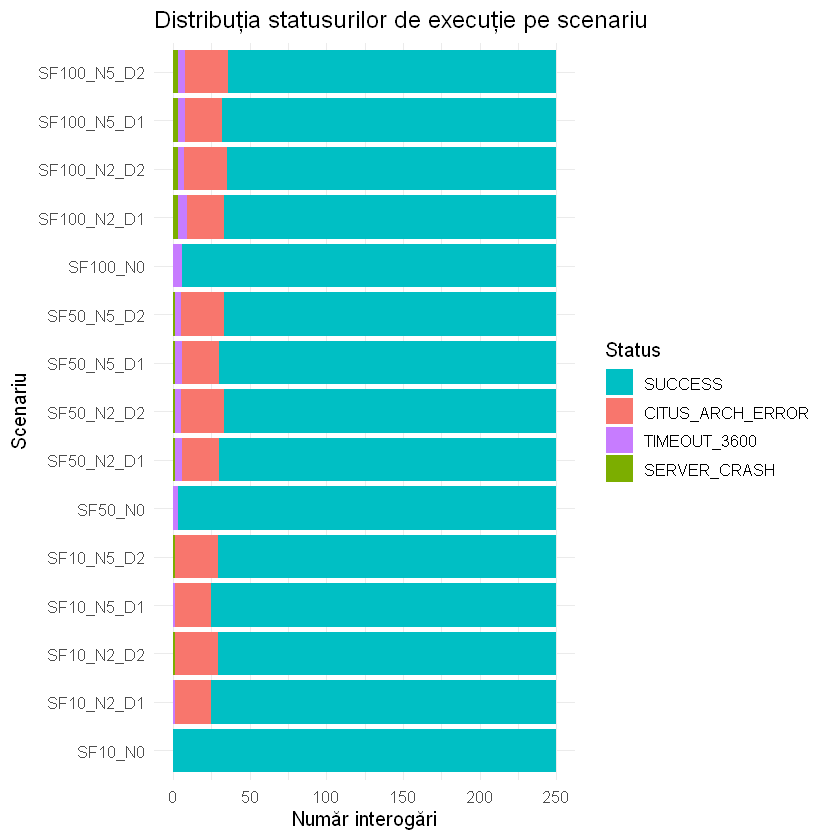

In [13]:
p_status_by_scenario <- status_by_scenario %>%
  ggplot(aes(x = scenario, y = n_queries, fill = status)) +
  geom_col() +
  coord_flip() +
  scale_fill_manual(values = status_colors) +
  labs(
    title = "Distribuția statusurilor de execuție pe scenariu",
    x = "Scenariu",
    y = "Număr interogări",
    fill = "Status"
  ) +
  theme_minimal(base_size = 12)

p_status_by_scenario

ggsave(
  filename = file.path(figures_dir, "plot_status_by_scenario.png"),
  plot = p_status_by_scenario,
  width = 11,
  height = 7,
  dpi = 300
)

Distribuția statusurilor pe scenarii arată că scenariile baseline au cele mai ridicate rate de succes, iar execuțiile distribuite introduc un număr mai mare de cazuri nefinalizate. 

Diferența nu este explicată doar prin timeout-uri sau crash-uri, ci mai ales prin `CITUS_ARCH_ERROR`, ceea ce indică existența unor limitări arhitecturale asociate execuției distribuite cu Citus.

În scenariile distribuite, ponderea execuțiilor cu succes rămâne ridicată, dar scade față de baseline.

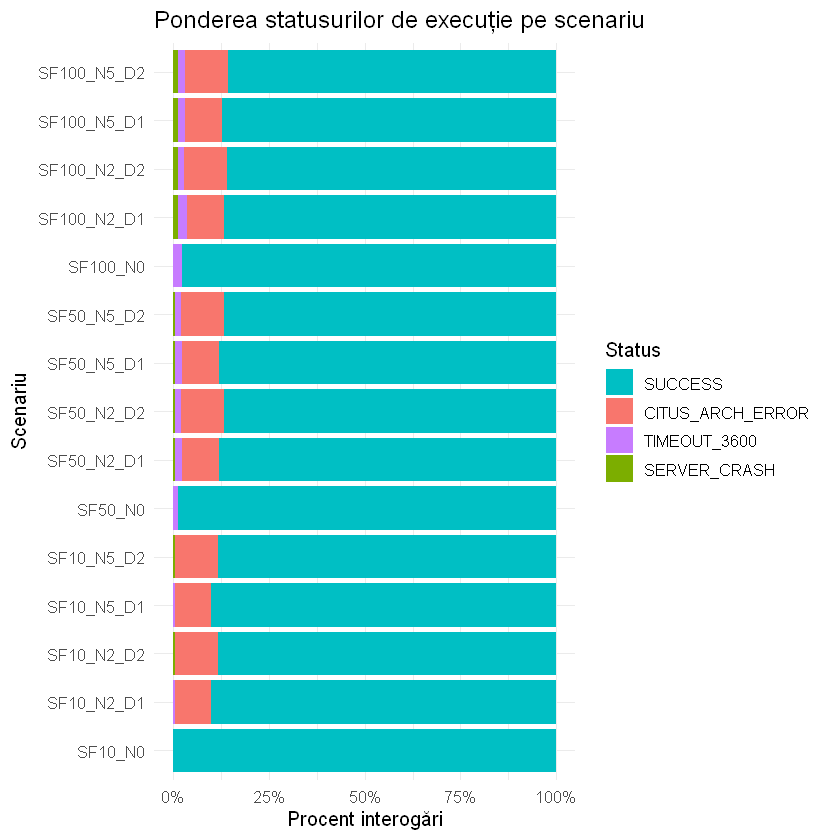

In [14]:
p_status_pct_by_scenario <- status_by_scenario %>%
  ggplot(aes(x = scenario, y = pct_queries, fill = status)) +
  geom_col() +
  coord_flip() +
  scale_y_continuous(labels = percent_format()) +
  scale_fill_manual(values = status_colors) +
  labs(
    title = "Ponderea statusurilor de execuție pe scenariu",
    x = "Scenariu",
    y = "Procent interogări",
    fill = "Status"
  ) +
  theme_minimal(base_size = 12)

p_status_pct_by_scenario

ggsave(
  filename = file.path(figures_dir, "plot_status_pct_by_scenario.png"),
  plot = p_status_pct_by_scenario,
  width = 11,
  height = 7,
  dpi = 300
)

In [15]:
success_rate_by_scenario <- results_master %>%
  group_by(scenario, sf, workers, strategy) %>%
  summarise(
    total_queries = n(),
    n_success = sum(status == "SUCCESS", na.rm = TRUE),
    success_rate = n_success / total_queries,
    .groups = "drop"
  ) %>%
  mutate(
    scenario = factor(scenario, levels = scenario_order)
  ) %>%
  arrange(sf, workers, strategy)

write_csv(
  success_rate_by_scenario,
  file.path(tables_dir, "summary_success_rate_by_scenario.csv")
)

success_rate_by_scenario

scenario,sf,workers,strategy,total_queries,n_success,success_rate
<fct>,<dbl>,<dbl>,<chr>,<int>,<int>,<dbl>
SF10_N0,10,0,baseline,250,250,1.000
SF10_N2_D1,10,2,D1,250,225,0.900
SF10_N2_D2,10,2,D2,250,221,0.884
SF10_N5_D1,10,5,D1,250,225,0.900
SF10_N5_D2,10,5,D2,250,221,0.884
SF50_N0,50,0,baseline,250,247,0.988
SF50_N2_D1,50,2,D1,250,220,0.880
SF50_N2_D2,50,2,D2,250,217,0.868
SF50_N5_D1,50,5,D1,250,220,0.880


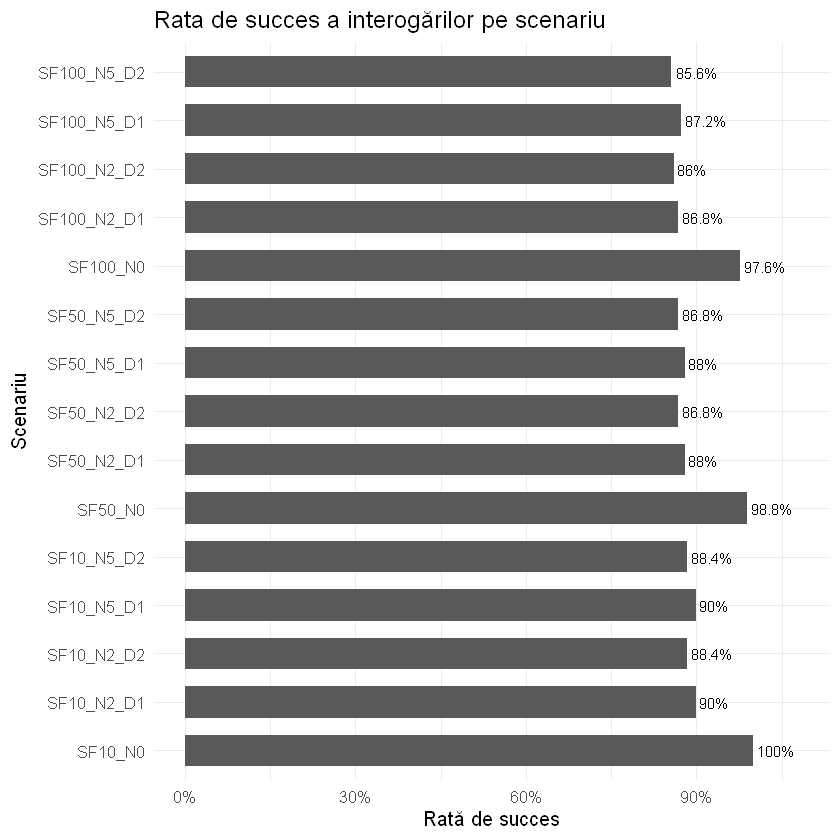

In [16]:
p_success_rate <- success_rate_by_scenario %>%
  ggplot(aes(x = scenario, y = success_rate)) +
  geom_col(width = 0.65) +
  geom_text(
    aes(label = paste0(round(success_rate * 100, 1), "%")),
    hjust = -0.1,
    size = 3.2
  ) +
  coord_flip() +
  scale_y_continuous(
    labels = percent_format(),
    limits = c(0, 1.08)
  ) +
  labs(
    title = "Rata de succes a interogărilor pe scenariu",
    x = "Scenariu",
    y = "Rată de succes"
  ) +
  theme_minimal(base_size = 12)

p_success_rate

ggsave(
  filename = file.path(figures_dir, "plot_success_rate_by_scenario.png"),
  plot = p_success_rate,
  width = 10,
  height = 7,
  dpi = 300
)

Rata de succes pe scenariu confirmă diferența dintre baseline și configurațiile distribuite. Scenariile baseline au rate de succes foarte ridicate: 100,0% la SF10, 98,8% la SF50 și 97,6% la SF100.

În scenariile distribuite, rata de succes variază între 85,6% și 90,0%. Pentru SF10, scenariile D1 ating 90,0%, iar D2 ajunge la 88,4%. La SF50, D1 are 88,0%, iar D2 are 86,8%. La SF100, valorile sunt apropiate, între 85,6% și 87,2%.

Se observă astfel că arhitectura distribuită nu reduce doar timpul de execuție pentru anumite interogări, ci introduce și o scădere a executabilității. Diferențele dintre D1 și D2 sunt relativ mici, dar D1 are constant o rată de succes ușor mai mare decât D2.

In [17]:
error_summary <- results_master %>%
  filter(status != "SUCCESS") %>%
  count(scenario, status, error_category, name = "n_queries") %>%
  mutate(
    scenario = factor(scenario, levels = scenario_order),
    status = factor(status, levels = status_order)
  ) %>%
  arrange(scenario, desc(n_queries))

write_csv(
  error_summary,
  file.path(tables_dir, "summary_errors_by_scenario.csv")
)

error_summary

scenario,status,error_category,n_queries
<fct>,<fct>,<chr>,<int>
SF10_N2_D1,CITUS_ARCH_ERROR,Join complex intre tabele distribuite necolocate,11
SF10_N2_D1,CITUS_ARCH_ERROR,Parallel DDL + FK catre reference table,7
SF10_N2_D1,CITUS_ARCH_ERROR,GROUPING SETS / CUBE / ROLLUP fara filtru pe cheia de distributie,2
SF10_N2_D1,CITUS_ARCH_ERROR,Subquery in lista SELECT nepusa in push-down,2
SF10_N2_D1,CITUS_ARCH_ERROR,Alta limitare arhitecturala Citus,1
SF10_N2_D1,CITUS_ARCH_ERROR,Recursive CTE neexecutabil distribuit in forma curenta,1
SF10_N2_D1,TIMEOUT_3600,Timeout peste pragul de 3600 secunde,1
SF10_N2_D2,CITUS_ARCH_ERROR,Join complex intre tabele distribuite necolocate,11
SF10_N2_D2,CITUS_ARCH_ERROR,Parallel DDL + FK catre reference table,10


**Observație.** Categoriile de erori CITUS_ARCH_ERROR sunt invariante față de SF și numărul de workeri: D1 produce constant 24 de erori arhitecturale per scenariu, D2 constant 28. Asta indică faptul că eșecurile arhitecturale sunt deterministe la nivel de pereche (interogare, strategie de distribuire) și nu depind de volumul de date sau de paralelizare.

Diferența fixă de 4 erori suplimentare la D2 provine din strategia de distribuire. D1 colochează toate tabelele fapt pe aceeași cheie (`item_sk`), creând un context de execuție consecvent. D2 distribuie fiecare canal pe cheia proprie, fragmentând tranzacțiile și înmulțind conflictele cu cheile externe către tabelele dimensionale (`item`, `store`, `date_dim`) - de aici creșterea de la 7 la 10 a erorilor „Parallel DDL + FK". Restul categoriilor depind de construcțiile SQL, nu de strategie, și sunt similare între D1 și D2.

TIMEOUT_3600 crește cu SF: 0 erori în SF10 baseline, 3 în SF50 baseline, 6 în SF100 baseline; în scenariile distribuite valorile sunt similare (1 la SF10, între 4 și 5 la SF50, între 4 și 6 la SF100) — comportament dependent de volum. 

SERVER_CRASH apare exclusiv în scenariile distribuite și se intensifică la SF100, unde se înregistrează 3 crash-uri în fiecare scenariu distribuit, față de doar 1 la SF10 și SF50.

In [20]:
problematic_queries <- results_master %>%
  filter(status != "SUCCESS") %>%
  select(
    scenario, sf, workers, strategy,
    query_id, query_no, status, error_category,
    elapsed_sec, response_code, response_message,
    source_file
  ) %>%
  arrange(scenario, query_no)

write_csv(
  problematic_queries,
  file.path(tables_dir, "problematic_queries.csv")
)

problematic_queries

scenario,sf,workers,strategy,query_id,query_no,status,error_category,elapsed_sec,response_code,response_message,source_file
<chr>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>
SF100_N0,100,0,baseline,Q024,24,TIMEOUT_3600,Timeout peste pragul de 3600 secunde,3602.081,57014 0,org.postgresql.util.PSQLException: ERROR: canceling statement due to user request,rezultate_sf100_n0_baseline.csv
SF100_N0,100,0,baseline,Q064,64,TIMEOUT_3600,Timeout peste pragul de 3600 secunde,3602.078,57014 0,org.postgresql.util.PSQLException: ERROR: canceling statement due to user request,rezultate_sf100_n0_baseline.csv
SF100_N0,100,0,baseline,Q099,99,TIMEOUT_3600,Timeout peste pragul de 3600 secunde,3600.593,57014 0,org.postgresql.util.PSQLException: ERROR: canceling statement due to user request,rezultate_sf100_n0_baseline.csv
SF100_N0,100,0,baseline,Q101,101,TIMEOUT_3600,Timeout peste pragul de 3600 secunde,3608.487,57014 0,org.postgresql.util.PSQLException: ERROR: canceling statement due to user request,rezultate_sf100_n0_baseline.csv
SF100_N0,100,0,baseline,Q125,125,TIMEOUT_3600,Timeout peste pragul de 3600 secunde,3600.044,57014 0,org.postgresql.util.PSQLException: ERROR: canceling statement due to user request,rezultate_sf100_n0_baseline.csv
SF100_N0,100,0,baseline,Q128,128,TIMEOUT_3600,Timeout peste pragul de 3600 secunde,3600.365,57014 0,org.postgresql.util.PSQLException: ERROR: canceling statement due to user request,rezultate_sf100_n0_baseline.csv
SF100_N2_D1,100,2,D1,Q013,13,CITUS_ARCH_ERROR,Join complex intre tabele distribuite necolocate,0.013,0A000 0,org.postgresql.util.PSQLException: ERROR: complex joins are only supported when all distributed tables are co-located and joined on their distribution columns,rezultate_sf100_n2_d1.csv
SF100_N2_D1,100,2,D1,Q028,28,TIMEOUT_3600,Timeout peste pragul de 3600 secunde,3600.375,57014 0,org.postgresql.util.PSQLException: ERROR: canceling statement due to user request,rezultate_sf100_n2_d1.csv
SF100_N2_D1,100,2,D1,Q051,51,CITUS_ARCH_ERROR,Parallel DDL + FK catre reference table,0.109,XX000 0,"org.postgresql.util.PSQLException: ERROR: cannot execute parallel DDL on table ""store_sales"" after DDL command on reference table ""date_dim"" because there is a foreign key between them and ""date_dim"" has been accessed in this transaction Detail: When there is a foreign key to a reference table, Citus needs to perform all operations over a single connection per node to ensure consistency. Hint: Try re-running the transaction with ""SET LOCAL citus.multi_shard_modify_mode TO 'sequential';""",rezultate_sf100_n2_d1.csv


**Observație.** Aceeași listă de interogări eșuează în toate scenariile distribuite (24 pe D1 și 28 pe D2), ceea ce indică determinism la nivel de interogare pentru eșecurile arhitecturale. Cele 11 interogări cu join-uri necolocate (Q013, Q065, Q069, Q124, Q125, Q160, Q197, Q198, Q233, Q235, Q248) apar identic în toate scenariile D1 și D2. 

Cele trei interogări critice se comportă diferit în funcție de SF:

- **Q101 — eșuează în toate scenariile distribuite, indiferent de SF:**
  - SF10 distribuit: timeout pe D1, SERVER_CRASH pe D2
  - SF50 și SF100 distribuit: SERVER_CRASH în toate cele patru combinații (N2/N5 × D1/D2)
  - În baseline: reușește la SF10, timeout la SF50 și SF100

- **Q183 și Q184 — eșuează exclusiv la SF100 distribuit:**
  - SF10 și SF50: reușesc în toate scenariile
  - SF100 baseline: reușesc
  - SF100 distribuit: SERVER_CRASH în toate cele patru combinații (N2/N5 × D1/D2)

## Analiza timpilor de execuție pentru interogările finalizate cu succes

In [23]:
success_results <- results_master %>%
  filter(status == "SUCCESS") %>%
  mutate(
    scenario = factor(scenario, levels = scenario_order)
  )

success_results %>%
  summarise(
    total_success = n(),
    total_scenarii = n_distinct(scenario),
    total_query_ids = n_distinct(query_id)
  )

total_success,total_scenarii,total_query_ids
<int>,<int>,<int>
3371,15,250


Pentru analiza din această secțiune sunt vizate cele 3371 de observații corespunzătoare interogărilor executate cu succes.

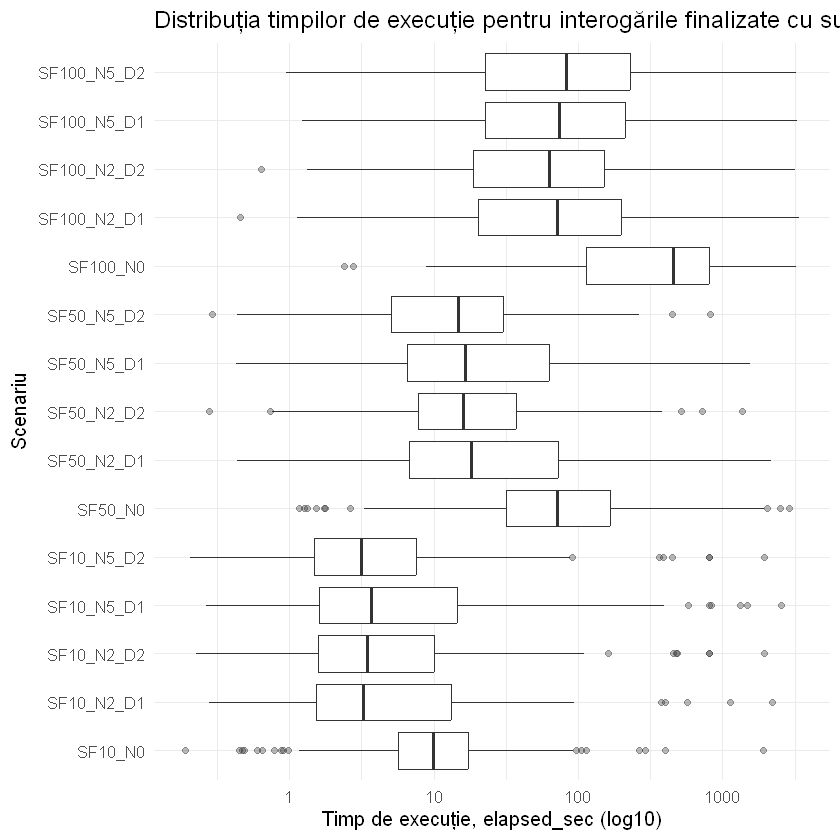

In [25]:
p_elapsed_boxplot <- success_results %>%
  filter(elapsed_sec > 0) %>%
  ggplot(aes(x = scenario, y = elapsed_sec)) +
  geom_boxplot(outlier.alpha = 0.35) +
  coord_flip() +
  scale_y_log10() +
  labs(
    title = "Distribuția timpilor de execuție pentru interogările finalizate cu succes",
    x = "Scenariu",
    y = "Timp de execuție, elapsed_sec (log10)"
  ) +
  theme_minimal(base_size = 12)

p_elapsed_boxplot

ggsave(
  filename = file.path(figures_dir, "plot_elapsed_boxplot_by_scenario_log10.png"),
  plot = p_elapsed_boxplot,
  width = 11,
  height = 7,
  dpi = 300
)

Boxplot-ul evidențiază patru aspecte importante privind relația dintre arhitectură, volumul de date și timpii de execuție.

În primul rând, scenariile distribuite PostgreSQL/Citus au mediane vizibil mai mici decât scenariile baseline pentru toate cele trei niveluri ale scale factorului. Acest lucru sugerează că distribuirea datelor poate reduce timpul de execuție pentru interogările finalizate cu succes.

În al doilea rând, diferența dintre baseline și scenariile distribuite pare să devină mai pronunțată odată cu creșterea volumului de date. La SF10, diferența este vizibilă, dar moderată; la SF50 și mai ales la SF100, scenariile distribuite se separă mai clar de baseline. Acest comportament este compatibil cu așteptarea ca o arhitectură distribuită să devină mai utilă pe măsură ce volumul de date crește.

În al treilea rând, diferențele dintre N2 și N5, respectiv dintre D1 și D2, par mai reduse decât diferența dintre baseline și scenariile distribuite. În interiorul aceluiași scale factor, boxplot-urile scenariilor distribuite au mediane și intervale intercuartilice relativ apropiate. Acest lucru sugerează că, pentru interogările executate cu succes, efectul principal este trecerea de la mononod la distribuit, în timp ce efectele suplimentare ale scalării de la 2 la 5 workeri și ale strategiei D1/D2 trebuie analizate separat.

În al patrulea rând, distribuțiile timpilor sunt puternic asimetrice, cu valori extreme și cozi lungi spre dreapta. Acest lucru confirmă că mediana, percentila 90 și percentila 95 sunt mai potrivite decât media pentru interpretarea performanței. 

Reprezentarea pe scala log10 este justificată deoarece timpii de execuție variază foarte mult, Scala logaritmică permite compararea mai clară a scenariilor.

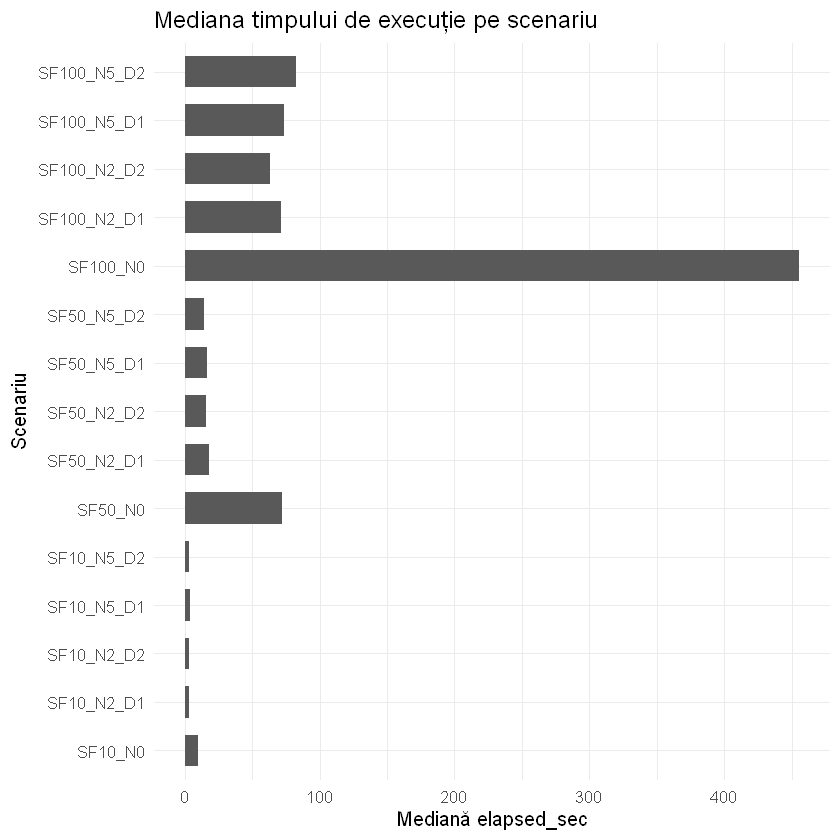

In [26]:
p_median_elapsed <- time_summary_by_scenario %>%
  mutate(
    scenario = factor(scenario, levels = scenario_order)
  ) %>%
  ggplot(aes(x = scenario, y = median_elapsed_sec)) +
  geom_col(width = 0.65) +
  coord_flip() +
  labs(
    title = "Mediana timpului de execuție pe scenariu",
    x = "Scenariu",
    y = "Mediană elapsed_sec"
  ) +
  theme_minimal(base_size = 12)

p_median_elapsed

ggsave(
  filename = file.path(figures_dir, "plot_median_elapsed_by_scenario.png"),
  plot = p_median_elapsed,
  width = 10,
  height = 7,
  dpi = 300
)

Graficul medianei timpului de execuție arată că scenariile baseline au timpi mediani mai mari decât scenariile distribuite, mai ales la volumele de date mai mari. Diferența este moderată la SF10, dar devine mult mai vizibilă la SF50 și SF100.

La SF100, baseline-ul are cea mai mare mediană, depășind vizibil toate scenariile distribuite. În schimb, configurațiile PostgreSQL/Citus rămân la valori mediane considerabil mai mici, indiferent de numărul de workeri sau de strategia de distribuire.

În interiorul scenariilor distribuite, diferențele dintre N2 și N5, respectiv dintre D1 și D2, sunt relativ reduse comparativ cu diferența dintre baseline și distribuit.

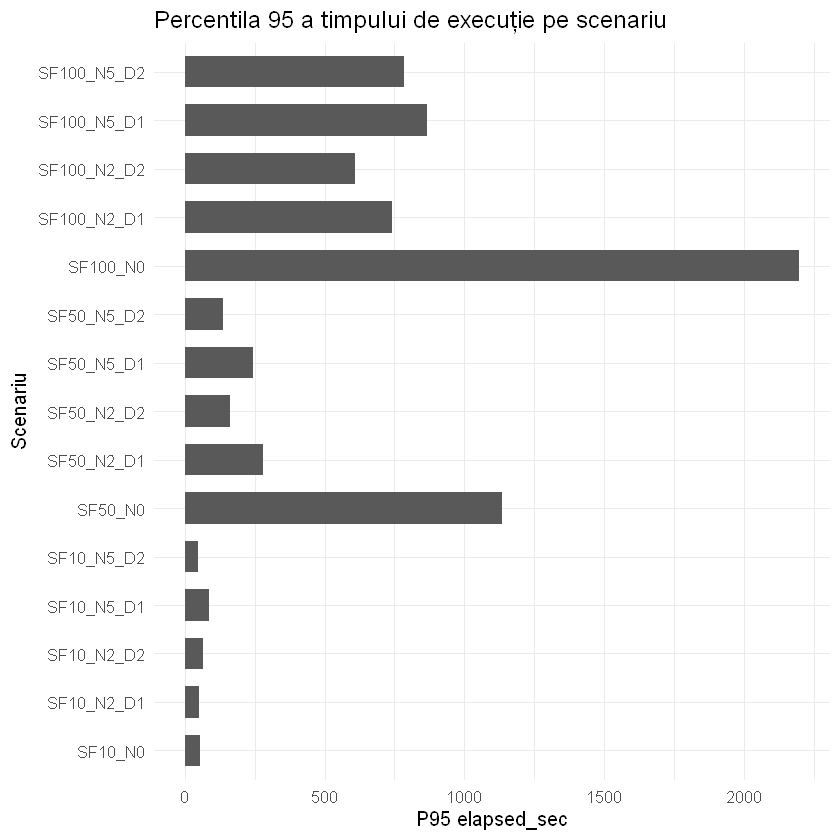

In [27]:
p_p95_elapsed <- time_summary_by_scenario %>%
  mutate(
    scenario = factor(scenario, levels = scenario_order)
  ) %>%
  ggplot(aes(x = scenario, y = p95_elapsed_sec)) +
  geom_col(width = 0.65) +
  coord_flip() +
  labs(
    title = "Percentila 95 a timpului de execuție pe scenariu",
    x = "Scenariu",
    y = "P95 elapsed_sec"
  ) +
  theme_minimal(base_size = 12)

p_p95_elapsed

ggsave(
  filename = file.path(figures_dir, "plot_p95_elapsed_by_scenario.png"),
  plot = p_p95_elapsed,
  width = 10,
  height = 7,
  dpi = 300
)

Graficul percentilei 95 evidențiază comportamentul interogărilor cu timpi ridicați de execuție. La fel ca în cazul medianei, baseline-ul are cele mai mari valori P95, în special la SF50 și SF100.

La SF100, P95 pentru baseline este mult peste valorile scenariilor distribuite, ceea ce indică faptul că arhitectura distribuită reduce nu doar timpul tipic de execuție, ci și valorile ridicate din coada superioară a distribuției. Totuși, P95 rămâne ridicat și în scenariile distribuite la SF100, ceea ce arată că anumite interogări continuă să fie costisitoare chiar și în configurațiile Citus.

Comparativ cu graficul medianei, P95 arată mai clar existența unor interogări grele, cu timpi mult peste comportamentul general.

In [28]:
success_results <- results_master %>%
  filter(status == "SUCCESS") %>%
  mutate(
    scenario = factor(scenario, levels = scenario_order)
  )

time_summary_success <- success_results %>%
  group_by(scenario, sf, workers, strategy) %>%
  summarise(
    n_success = n(),
    mean_sec = mean(elapsed_sec, na.rm = TRUE),
    median_sec = median(elapsed_sec, na.rm = TRUE),
    min_sec = min(elapsed_sec, na.rm = TRUE),
    max_sec = max(elapsed_sec, na.rm = TRUE),
    p90_sec = quantile(elapsed_sec, 0.90, na.rm = TRUE),
    p95_sec = quantile(elapsed_sec, 0.95, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  arrange(sf, workers, strategy)

write_csv(
  time_summary_success,
  file.path(tables_dir, "summary_time_success.csv")
)

time_summary_success

scenario,sf,workers,strategy,n_success,mean_sec,median_sec,min_sec,max_sec,p90_sec,p95_sec
<fct>,<dbl>,<dbl>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
SF10_N0,10,0,baseline,250,25.35139,9.8365,0.189,1899.119,27.6704,56.02955
SF10_N2_D1,10,2,D1,225,30.77181,3.2380,0.280,2218.742,33.4058,51.88680
SF10_N2_D2,10,2,D2,221,32.08433,3.4530,0.226,1943.045,25.5410,66.09300
SF10_N5_D1,10,5,D1,225,46.75850,3.6620,0.264,2551.418,39.2878,88.36560
SF10_N5_D2,10,5,D2,221,28.63714,3.1590,0.207,1949.428,23.6670,48.99600
SF50_N0,50,0,baseline,247,205.79436,72.0280,1.175,2897.740,386.4950,1136.57940
SF50_N2_D1,50,2,D1,220,83.23755,18.1955,0.438,2174.796,146.0820,279.81895
SF50_N2_D2,50,2,D2,217,47.18957,16.0050,0.278,1373.739,101.6022,162.50500
SF50_N5_D1,50,5,D1,220,67.34767,16.5835,0.426,1542.740,142.0739,243.88470


Tabelul confirmă diferențele observate în grafice. La nivel de mediană, baseline-ul crește puternic odată cu volumul de date: de la 9,84 secunde la SF10, la 72,03 secunde la SF50 și 455,37 secunde la SF100. În scenariile distribuite, medianele sunt considerabil mai mici: aproximativ 3,16–3,66 secunde la SF10, 14,64–18,20 secunde la SF50 și 63,12–82,24 secunde la SF100.

Diferența este mai pronunțată la volume mari. La SF100, scenariul baseline are o mediană de 455,37 secunde, în timp ce scenariile distribuite se situează între 63,12 și 82,24 secunde. Acest lucru indică un avantaj descriptiv important al arhitecturii PostgreSQL/Citus pentru interogările executate cu succes.

Percentila 95 confirmă același pattern. La SF50, baseline-ul are P95 de 1136,58 secunde, față de valori între 137,33 și 279,82 secunde în scenariile distribuite. La SF100, baseline-ul ajunge la 2196,60 secunde, în timp ce scenariile distribuite rămân între 610,63 și 865,35 secunde.

Totuși, valorile maxime rămân ridicate în toate scenariile, inclusiv în cele distribuite, ceea ce arată că anumite interogări continuă să aibă timpi foarte mari de execuție. De aceea, analiza medianei și a percentililor superiori este mai relevantă decât interpretarea exclusivă a mediei.

## Comparația baseline vs scenarii distribuite

In [45]:
baseline_times <- results_master %>%
  filter(strategy == "baseline", status == "SUCCESS") %>%
  select(sf, query_id, baseline_elapsed_sec = elapsed_sec)

distributed_times <- results_master %>%
  filter(strategy != "baseline", status == "SUCCESS") %>%
  select(scenario, sf, workers, strategy, query_id, distributed_elapsed_sec = elapsed_sec)

speedup_df <- distributed_times %>%
  inner_join(baseline_times, by = c("sf", "query_id")) %>%
  mutate(
    speedup = baseline_elapsed_sec / distributed_elapsed_sec,
    speedup_class = case_when(
      speedup > 1 ~ "Citus mai rapid",
      speedup < 1 ~ "Citus mai lent",
      TRUE ~ "Egal"
    ),
    scenario = factor(scenario, levels = scenario_order)
  )

write_csv(
  speedup_df,
  file.path(tables_dir, "speedup_vs_baseline.csv")
)

speedup_summary <- speedup_df %>%
  group_by(scenario, sf, workers, strategy) %>%
  summarise(
    n_compared_queries = n(),
    median_speedup = median(speedup, na.rm = TRUE),
    mean_speedup = mean(speedup, na.rm = TRUE),
    pct_faster = mean(speedup > 1, na.rm = TRUE) * 100,
    pct_slower = mean(speedup < 1, na.rm = TRUE) * 100,
    .groups = "drop"
  ) %>%
  arrange(sf, workers, strategy)

write_csv(
  speedup_summary,
  file.path(tables_dir, "summary_speedup_vs_baseline.csv")
)

speedup_summary

scenario,sf,workers,strategy,n_compared_queries,median_speedup,mean_speedup,pct_faster,pct_slower
<fct>,<dbl>,<dbl>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
SF10_N2_D1,10,2,D1,225,2.452937,3.491082,75.11111,24.888889
SF10_N2_D2,10,2,D2,221,2.560345,3.112579,80.54299,19.457014
SF10_N5_D1,10,5,D1,225,2.087361,3.285102,72.88889,27.111111
SF10_N5_D2,10,5,D2,221,2.693673,3.478398,84.61538,15.384615
SF50_N2_D1,50,2,D1,220,3.309881,9.271254,84.09091,15.909091
SF50_N2_D2,50,2,D2,217,3.857390,14.896286,89.86175,10.138249
SF50_N5_D1,50,5,D1,220,3.543436,10.536589,85.00000,15.000000
SF50_N5_D2,50,5,D2,217,4.593242,16.804029,93.54839,6.451613
SF100_N2_D1,100,2,D1,214,4.848415,13.596436,86.91589,13.084112


Tabelul arată că toate scenariile distribuite au mediana factorului de accelerare (`median_speedup`) mai mare decât 1, ceea ce indică timpi mai mici față de baseline pentru interogările executate cu succes în ambele scenarii comparate.

La SF10, valoarea variază între aproximativ 2,09 și 2,69, ceea ce sugerează o îmbunătățire moderată prin distribuire. La SF50, valorile cresc între 3,31 și 4,59, iar la SF100 între 4,03 și 5,19. Astfel, beneficiul arhitecturii distribuite devine mai pronunțat pe măsură ce volumul de date crește.

Procentul interogărilor mai rapide în scenariile distribuite este ridicat în toate cazurile, variind între aproximativ 72,9% și 93,5%. Cele mai mari ponderi apar la SF50_N5_D2, unde 93,5% dintre interogările comparabile sunt mai rapide decât în baseline, și la SF100_N2_D2, unde procentul este de 91,6%.

Rezultatele susțin descriptiv ideea că PostgreSQL/Citus reduce timpul de execuție pentru majoritatea interogărilor finalizate cu succes. Totuși, comparația este calculată doar pe interogările care au rulat cu succes în ambele scenarii, deci trebuie interpretată împreună cu analiza executabilității.

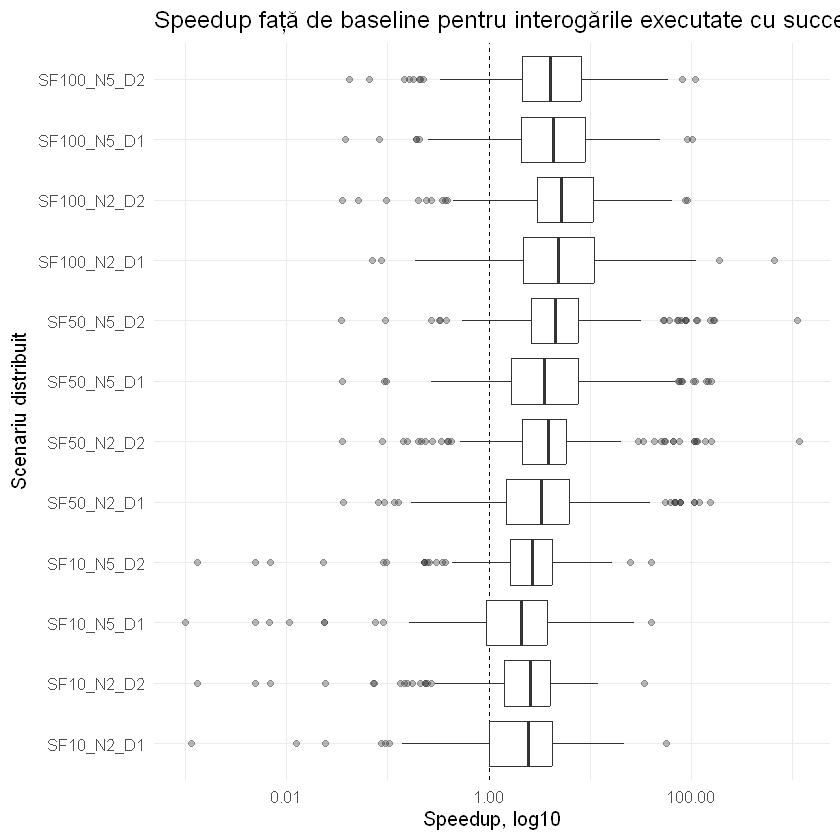

In [31]:
p_speedup <- speedup_df %>%
  ggplot(aes(x = scenario, y = speedup)) +
  geom_hline(yintercept = 1, linetype = "dashed") +
  geom_boxplot(outlier.alpha = 0.35) +
  coord_flip() +
  scale_y_log10(labels = comma_format()) +
  labs(
    title = "Speedup față de baseline pentru interogările executate cu succes",
    x = "Scenariu distribuit",
    y = "Speedup, log10"
  ) +
  theme_minimal(base_size = 12)

p_speedup

ggsave(
  filename = file.path(figures_dir, "plot_speedup_vs_baseline.png"),
  plot = p_speedup,
  width = 13,
  height = 7,
  dpi = 300
)

Boxplot-ul pentru `speedup` confirmă rezultatele din tabel: în toate scenariile distribuite, mediana se află peste pragul 1, marcat prin linia punctată. Acest lucru indică faptul că, pentru interogările comparabile, scenariile PostgreSQL/Citus sunt în general mai rapide decât baseline-ul PostgreSQL mononod.

Diferența față de baseline este vizibilă pentru toate scale factor-urile, dar devine mai pronunțată la SF50 și SF100. La aceste volume, distribuțiile sunt deplasate mai clar spre valori mai mari de 1, ceea ce sugerează un avantaj mai consistent al arhitecturii distribuite.

Totuși, graficul arată și existența unor valori sub 1, deci nu toate interogările beneficiază de distribuire. Pentru o parte dintre query-uri, scenariul distribuit este mai lent decât baseline-ul, probabil din cauza costurilor suplimentare de coordonare, de comunicație între noduri sau de redistribuire a datelor.

Prin urmare, **rezultatul susține descriptiv RQ1: distribuirea cu Citus îmbunătățește performanța pentru majoritatea interogărilor reușite, dar beneficiul nu este uniform pentru întregul workload.**

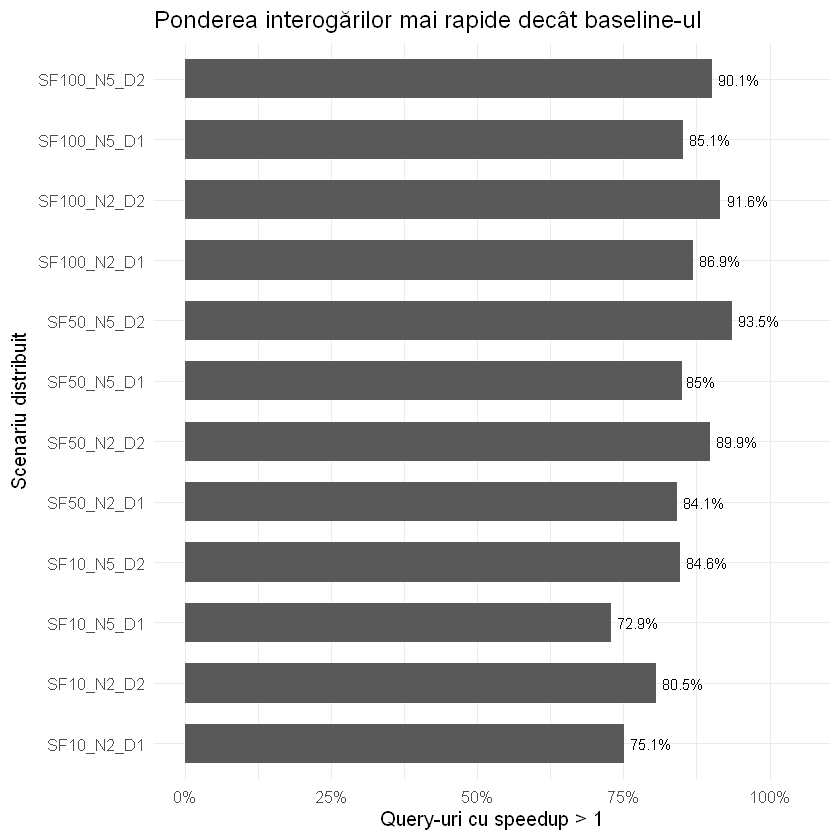

In [32]:
p_speedup_pct <- speedup_summary %>%
  mutate(
    scenario = factor(scenario, levels = scenario_order)
  ) %>%
  ggplot(aes(x = scenario, y = pct_faster)) +
  geom_col(width = 0.65) +
  geom_text(
    aes(label = paste0(round(pct_faster, 1), "%")),
    hjust = -0.15,
    size = 3.2
  ) +
  coord_flip() +
  scale_y_continuous(
    limits = c(0, 105),
    labels = function(x) paste0(x, "%")
  ) +
  labs(
    title = "Ponderea interogărilor mai rapide decât baseline-ul",
    x = "Scenariu distribuit",
    y = "Query-uri cu speedup > 1"
  ) +
  theme_minimal(base_size = 12)

p_speedup_pct

ggsave(
  filename = file.path(figures_dir, "plot_speedup_percent_faster.png"),
  plot = p_speedup_pct,
  width = 11,
  height = 7,
  dpi = 300
)

Graficul arată că, în toate scenariile distribuite, majoritatea interogărilor comparabile sunt mai rapide decât în baseline. Ponderea query-urilor cu `speedup > 1` variază între 72,9% și 93,5%, ceea ce indică un avantaj consistent al PostgreSQL/Citus pentru interogările finalizate cu succes în ambele scenarii.

Cele mai mari ponderi apar la SF50_N5_D2, cu 93,5%, și SF100_N2_D2, cu 91,6%. La SF10, ponderea este mai redusă, între 72,9% și 84,6%, ceea ce sugerează că beneficiul distribuției este mai moderat la volume mici de date.

Rezultatul completează analiza medianei speedup-ului: nu doar că scenariile distribuite au timpi mediani mai mici, dar această îmbunătățire apare pentru o proporție mare a interogărilor comparabile. Totuși, există în continuare un segment de interogări pentru care distribuirea nu aduce câștig de performanță, ceea ce justifică analiza ulterioară a caracteristicilor structurale ale query-urilor.

## Comparația dintre D1 și D2 pe baza timpilor de execuție

In [34]:
d1_d2_df <- results_master %>%
  filter(strategy %in% c("D1", "D2"), status == "SUCCESS") %>%
  select(sf, workers, strategy, query_id, elapsed_sec) %>%
  pivot_wider(
    names_from = strategy,
    values_from = elapsed_sec,
    names_prefix = "elapsed_"
  ) %>%
  filter(!is.na(elapsed_D1), !is.na(elapsed_D2)) %>%
  mutate(
    ratio_d2_over_d1 = elapsed_D2 / elapsed_D1,
    faster_strategy = case_when(
      ratio_d2_over_d1 > 1 ~ "D1 mai rapid",
      ratio_d2_over_d1 < 1 ~ "D2 mai rapid",
      TRUE ~ "Egal"
    )
  )

write_csv(
  d1_d2_df,
  file.path(tables_dir, "comparison_d1_vs_d2.csv")
)

d1_d2_summary <- d1_d2_df %>%
  group_by(sf, workers) %>%
  summarise(
    n_compared_queries = n(),
    median_ratio_d2_over_d1 = median(ratio_d2_over_d1, na.rm = TRUE),
    mean_ratio_d2_over_d1 = mean(ratio_d2_over_d1, na.rm = TRUE),
    pct_d1_faster = mean(ratio_d2_over_d1 > 1, na.rm = TRUE) * 100,
    pct_d2_faster = mean(ratio_d2_over_d1 < 1, na.rm = TRUE) * 100,
    .groups = "drop"
  ) %>%
  arrange(sf, workers)

write_csv(
  d1_d2_summary,
  file.path(tables_dir, "summary_d1_vs_d2.csv")
)

d1_d2_summary

sf,workers,n_compared_queries,median_ratio_d2_over_d1,mean_ratio_d2_over_d1,pct_d1_faster,pct_d2_faster
<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
10,2,216,0.9392298,1.765897,41.20370,58.79630
10,5,216,0.8400091,1.072730,29.16667,70.37037
50,2,211,0.8672534,1.259652,38.38863,61.61137
50,5,211,0.8301055,0.936032,25.11848,74.88152
100,2,207,0.9077687,1.633173,42.51208,57.48792
100,5,208,0.9968330,1.663869,49.51923,50.48077


Tabelul compară strategiile D1 și D2 doar pentru interogările executate cu succes în ambele strategii. 

La nivelul medianei, toate combinațiile analizate au valori sub 1, ceea ce sugerează că D2 are, în general, un avantaj ușor față de D1 pentru interogările comparabile. Cele mai clare diferențe apar la SF10 cu 5 workeri și la SF50, unde mediana raportului este în jur de 0,83–0,87.

**Totuși, diferențele nu sunt foarte mari, iar procentele arată că nu există o dominanță absolută. D2 este mai rapidă în aproximativ 50,5%–74,9% dintre cazuri, în funcție de scenariu, în timp ce D1 rămâne mai rapidă pentru o parte importantă dintre interogări. Prin urmare, avantajul D2 este descriptiv, dar nu uniform pentru întregul workload.**

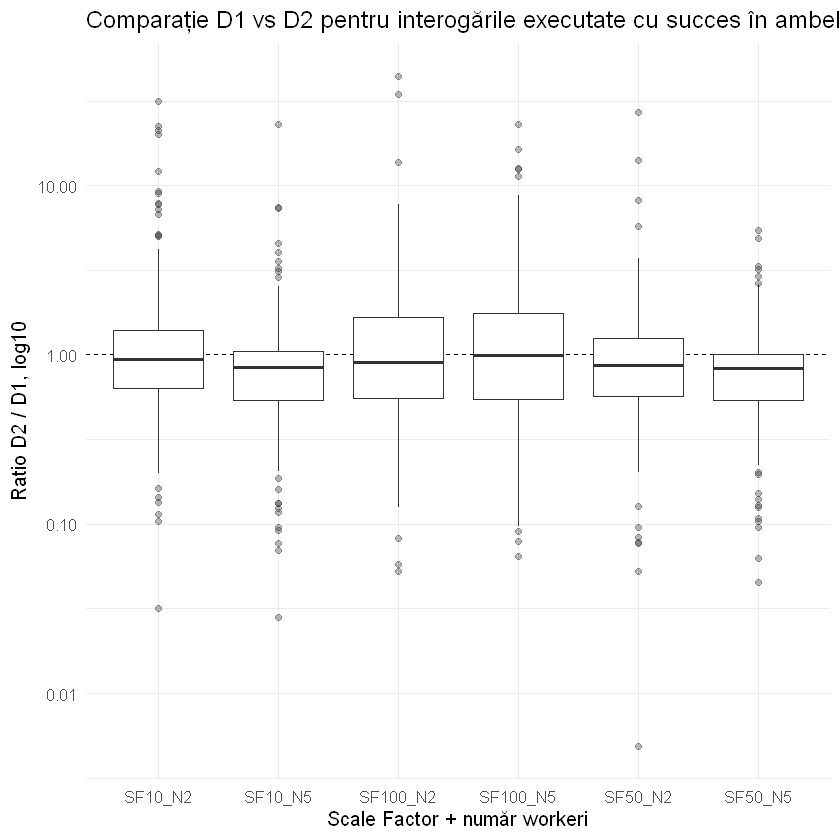

In [35]:
p_d1_d2 <- d1_d2_df %>%
  mutate(scenario_pair = paste0("SF", sf, "_N", workers)) %>%
  ggplot(aes(x = scenario_pair, y = ratio_d2_over_d1)) +
  geom_hline(yintercept = 1, linetype = "dashed") +
  geom_boxplot(outlier.alpha = 0.35) +
  scale_y_log10(labels = comma_format()) +
  labs(
    title = "Comparație D1 vs D2 pentru interogările executate cu succes în ambele strategii",
    x = "Scale Factor + număr workeri",
    y = "Ratio D2 / D1, log10"
  ) +
  theme_minimal(base_size = 12)

p_d1_d2

ggsave(
  filename = file.path(figures_dir, "plot_d1_vs_d2_ratio.png"),
  plot = p_d1_d2,
  width = 10,
  height = 6,
  dpi = 300
)

Boxplot-ul confirmă caracterul variabil al diferențelor dintre D1 și D2. Linia punctată marchează valoarea 1, unde cele două strategii ar avea același timp de execuție. Majoritatea medianelor sunt ușor sub 1, ceea ce susține observația că D2 tinde să fie mai rapidă decât D1 pentru interogările executate cu succes în ambele scenarii.

Totuși, distribuțiile sunt largi și includ numeroase valori atât sub 1, cât și peste 1. Acest lucru arată că efectul strategiei de distribuire depinde de interogare: unele query-uri beneficiază de D2, în timp ce altele rulează mai bine cu D1.

Prin urmare, diferența D1 vs D2 nu pare la fel de puternică precum diferența baseline vs distribuit. Strategia de distribuire influențează performanța, dar efectul este mai nuanțat și trebuie interpretat împreună cu rata de succes și cu caracteristicile structurale ale interogărilor.

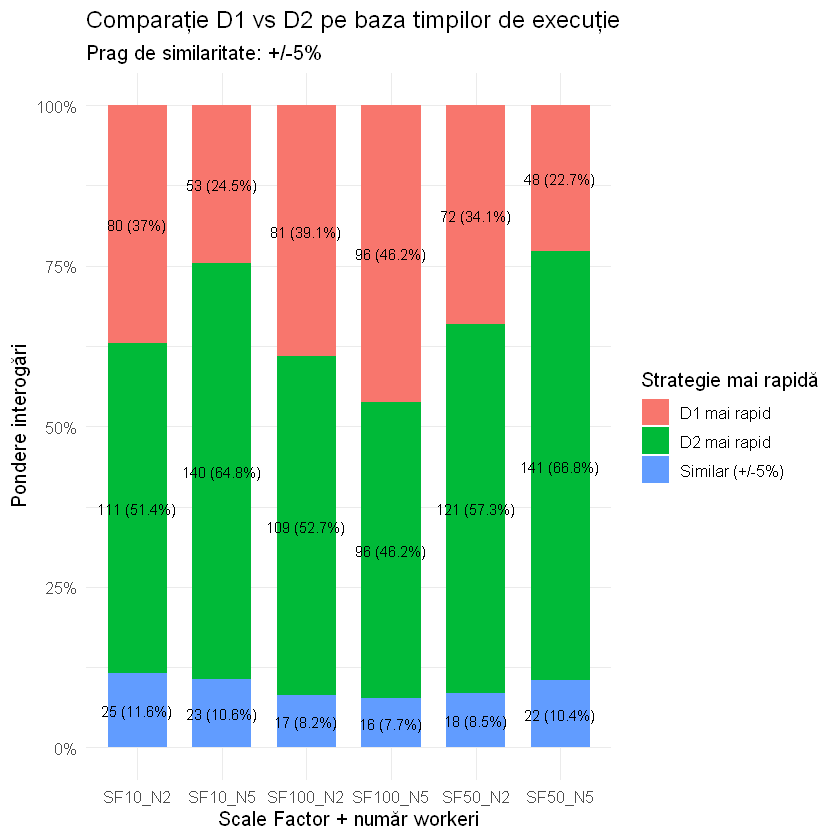

In [36]:
d1_d2_stacked <- d1_d2_df %>%
  mutate(
    scenario_pair = paste0("SF", sf, "_N", workers),
    comparison_class = case_when(
      ratio_d2_over_d1 > 1.05 ~ "D1 mai rapid",
      ratio_d2_over_d1 < 0.95 ~ "D2 mai rapid",
      TRUE ~ "Similar (+/-5%)"
    )
  ) %>%
  count(scenario_pair, comparison_class, name = "n_queries") %>%
  group_by(scenario_pair) %>%
  mutate(
    total_queries = sum(n_queries),
    pct_queries = n_queries / total_queries,
    label = paste0(n_queries, " (", round(pct_queries * 100, 1), "%)")
  ) %>%
  ungroup()

write_csv(
  d1_d2_stacked,
  file.path(tables_dir, "summary_d1_vs_d2_stacked.csv")
)

p_d1_d2_stacked <- d1_d2_stacked %>%
  ggplot(aes(x = scenario_pair, y = pct_queries, fill = comparison_class)) +
  geom_col(width = 0.7) +
  geom_text(
    aes(label = label),
    position = position_stack(vjust = 0.5),
    size = 3.2
  ) +
  scale_y_continuous(labels = percent_format(), limits = c(0, 1)) +
  labs(
    title = "Comparație D1 vs D2 pe baza timpilor de execuție",
    subtitle = "Prag de similaritate: +/-5%",
    x = "Scale Factor + număr workeri",
    y = "Pondere interogări",
    fill = "Strategie mai rapidă"
  ) +
  theme_minimal(base_size = 12)

p_d1_d2_stacked

ggsave(
  filename = file.path(figures_dir, "plot_d1_vs_d2_stacked_percent.png"),
  plot = p_d1_d2_stacked,
  width = 10,
  height = 6,
  dpi = 300
)

Ținând cont de pragul de similaritate de ±5%, observăm că în toate combinațiile analizate, D2 este mai rapidă pentru cea mai mare parte a interogărilor comparabile, cu ponderi între 46,2% și 66,8%.

Avantajul D2 este cel mai vizibil la SF50_N5, unde 66,8% dintre interogări rulează mai rapid cu D2, și la SF10_N5, unde ponderea este de 64,8%. La SF100_N5, distribuția este mai echilibrată: 46,2% dintre interogări sunt mai rapide cu D2 și 46,2% cu D1, ceea ce sugerează că diferența dintre strategii devine mai puțin clară în această configurație.

Categoria „Similar” are ponderi reduse, între 7,7% și 11,6%, ceea ce indică faptul că pentru majoritatea interogărilor există o diferență măsurabilă între D1 și D2, chiar dacă direcția acestei diferențe nu este aceeași pentru toate query-urile.

Prin urmare, D2 pare să aibă un avantaj descriptiv pe timpul de execuție, dar acesta nu este uniform. Alegerea strategiei de distribuire trebuie analizată împreună cu executabilitatea, deoarece D1 avea anterior o rată de succes ușor mai bună decât D2.

## Comparația dntre N2 și N5 pe baza timpilor de execuție

In [38]:
n2_n5_time_comparison <- results_master %>%
  filter(
    strategy %in% c("D1", "D2"),
    workers %in% c(2, 5),
    status == "SUCCESS"
  ) %>%
  select(sf, strategy, workers, query_id, elapsed_sec) %>%
  mutate(workers_label = paste0("N", workers)) %>%
  select(-workers) %>%
  pivot_wider(
    names_from = workers_label,
    values_from = elapsed_sec,
    names_prefix = "elapsed_"
  ) %>%
  filter(!is.na(elapsed_N2), !is.na(elapsed_N5)) %>%
  mutate(
    node_scaling_speedup = elapsed_N2 / elapsed_N5,
    time_reduction_pct = ((elapsed_N2 - elapsed_N5) / elapsed_N2) * 100,
    scaling_efficiency = node_scaling_speedup / (5 / 2),
    time_comparison_class = case_when(
      node_scaling_speedup > 1.05 ~ "N5 mai rapid",
      node_scaling_speedup < 0.95 ~ "N2 mai rapid",
      TRUE ~ "Similar (+/-5%)"
    )
  ) %>%
  arrange(sf, strategy, query_id)

write_csv(
  n2_n5_time_comparison,
  file.path(tables_dir, "comparison_n2_vs_n5_time.csv")
)

n2_n5_time_summary <- n2_n5_time_comparison %>%
  group_by(sf, strategy) %>%
  summarise(
    n_compared_queries = n(),
    median_elapsed_N2 = median(elapsed_N2, na.rm = TRUE),
    median_elapsed_N5 = median(elapsed_N5, na.rm = TRUE),
    median_node_scaling_speedup = median(node_scaling_speedup, na.rm = TRUE),
    mean_node_scaling_speedup = mean(node_scaling_speedup, na.rm = TRUE),
    median_time_reduction_pct = median(time_reduction_pct, na.rm = TRUE),
    mean_time_reduction_pct = mean(time_reduction_pct, na.rm = TRUE),
    median_scaling_efficiency = median(scaling_efficiency, na.rm = TRUE),
    pct_N5_faster = mean(time_comparison_class == "N5 mai rapid", na.rm = TRUE) * 100,
    pct_N2_faster = mean(time_comparison_class == "N2 mai rapid", na.rm = TRUE) * 100,
    pct_similar = mean(time_comparison_class == "Similar (+/-5%)", na.rm = TRUE) * 100,
    .groups = "drop"
  ) %>%
  arrange(sf, strategy)

write_csv(
  n2_n5_time_summary,
  file.path(tables_dir, "summary_n2_vs_n5_time.csv")
)

n2_n5_time_summary

sf,strategy,n_compared_queries,median_elapsed_N2,median_elapsed_N5,median_node_scaling_speedup,mean_node_scaling_speedup,median_time_reduction_pct,mean_time_reduction_pct,median_scaling_efficiency,pct_N5_faster,pct_N2_faster,pct_similar
<dbl>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
10,D1,225,3.2380,3.6620,0.9717918,1.018452,-2.9026983,-47.282283,0.3887167,17.33333,42.666667,40.00000
10,D2,221,3.4530,3.1590,1.0047481,1.584323,0.4725652,5.083914,0.4018992,33.48416,31.674208,34.84163
50,D1,220,18.1955,16.5835,1.0135741,1.317693,1.3392304,3.583483,0.4054296,38.63636,29.090909,32.27273
50,D2,217,16.0050,14.6410,1.0579332,1.650119,5.4760730,15.693657,0.4231733,52.99539,7.373272,39.63134
100,D1,217,71.5530,72.4930,0.9728259,1.005905,-2.7933160,-56.541289,0.3891304,31.79724,46.082949,22.11982
100,D2,214,62.9910,82.2360,0.9158902,1.033344,-9.1957584,-82.949164,0.3663561,32.24299,53.271028,14.48598


Tabelul arată că trecerea de la 2 la 5 workeri nu produce un câștig constant, măsurat prin node_scaling_speedup.

La SF10_D1, mediana timpului crește ușor de la 3,24 s în N2 la 3,66 s în N5, iar `median_node_scaling_speedup` este 0,97. Asta indică faptul că N5 nu aduce un avantaj pe mediană. La SF10_D2, diferența este foarte mică, cu 3,45 s în N2 și 3,16 s în N5, iar speedup-ul median este aproape 1,00.

La SF50, N5 devine mai avantajos. Pentru D1, mediana scade de la 18,20 s la 16,58 s, iar pentru D2 de la 16,01 s la 14,64 s. Cel mai clar câștig apare la SF50_D2, unde `median_node_scaling_speedup` este 1,06, iar reducerea mediană a timpului este de aproximativ 5,48%.

La SF100, rezultatul se inversează. Pentru D1, mediana este apropiată, 71,55 s în N2 și 72,49 s în N5, iar pentru D2 N5 este mai lent pe mediană: 82,24 s față de 62,99 s în N2. Astfel, la SF100_D2, `median_node_scaling_speedup` este 0,92, ceea ce indică un dezavantaj descriptiv pentru N5.

Prin urmare, scalarea de la 2 la 5 workeri nu garantează o reducere a timpului de execuție. Cel mai bun comportament apare la SF50, mai ales pentru D2, în timp ce la SF100 avantajul nu se menține.

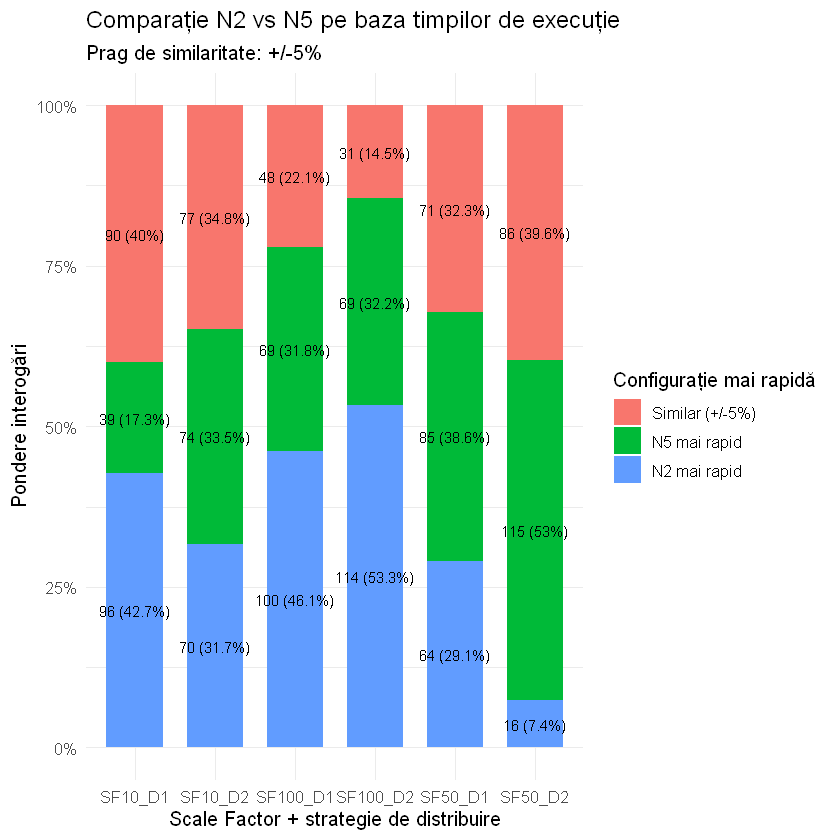

In [40]:
n2_n5_stacked_time <- n2_n5_time_comparison %>%
  mutate(
    scenario_pair = paste0("SF", sf, "_", strategy),
    comparison_class = factor(
      time_comparison_class,
      levels = c("Similar (+/-5%)", "N5 mai rapid", "N2 mai rapid")
    )
  ) %>%
  count(scenario_pair, sf, strategy, comparison_class, name = "n_queries") %>%
  group_by(scenario_pair, sf, strategy) %>%
  mutate(
    total_queries = sum(n_queries),
    pct_queries = n_queries / total_queries,
    label = paste0(n_queries, " (", round(pct_queries * 100, 1), "%)")
  ) %>%
  ungroup()

write_csv(
  n2_n5_stacked_time,
  file.path(tables_dir, "summary_n2_vs_n5_time_stacked.csv")
)

p_n2_n5_time_stacked <- n2_n5_stacked_time %>%
  ggplot(aes(x = scenario_pair, y = pct_queries, fill = comparison_class)) +
  geom_col(width = 0.7) +
  geom_text(
    aes(label = label),
    position = position_stack(vjust = 0.5),
    size = 3.2
  ) +
  scale_y_continuous(labels = percent_format(), limits = c(0, 1)) +
  labs(
    title = "Comparație N2 vs N5 pe baza timpilor de execuție",
    subtitle = "Prag de similaritate: +/-5%",
    x = "Scale Factor + strategie de distribuire",
    y = "Pondere interogări",
    fill = "Configurație mai rapidă"
  ) +
  theme_minimal(base_size = 12)

p_n2_n5_time_stacked

ggsave(
  filename = file.path(figures_dir, "plot_n2_vs_n5_time_stacked_percent.png"),
  plot = p_n2_n5_time_stacked,
  width = 13,
  height = 7,
  dpi = 300
)

Graficul confirmă că efectul scalării este diferit în funcție de scale factor și strategie. La SF50_D2, N5 este clar mai favorabil: 53,0% dintre interogări sunt mai rapide cu 5 workeri, doar 7,4% sunt mai rapide cu 2 workeri, iar 39,6% sunt similare.

La SF50_D1, rezultatul este mai echilibrat, dar tot în favoarea N5: 38,6% dintre interogări sunt mai rapide cu N5, 29,1% cu N2, iar 32,3% sunt similare.

La SF10 nu apare un avantaj clar al scalării. Pentru D1, N2 este mai rapid în 42,7% dintre cazuri, față de doar 17,3% pentru N5. Pentru D2, rezultatul este aproape echilibrat: 33,5% N5 mai rapid, 31,7% N2 mai rapid și 34,8% similar.

La SF100, N2 este mai favorabil descriptiv. Pentru D1, N2 este mai rapid în 46,1% dintre cazuri, față de 31,8% pentru N5. Pentru D2, diferența este și mai clară: N2 este mai rapid în 53,3% dintre cazuri, iar N5 doar în 32,2%.

Prin urmare, scalarea la 5 workeri are efect pozitiv mai ales la SF50, dar nu se comportă uniform la SF10 și SF100. Rezultatul sugerează că adăugarea de noduri poate introduce costuri suplimentare de coordonare, iar beneficiul depinde de volumul de date, strategia de distribuire și structura interogărilor.

## Comparația dintre D1 și D2 din perspectiva statusului de execuție

In [42]:
d1_d2_status_comparison <- results_master %>%
  filter(
    strategy %in% c("D1", "D2"),
    workers %in% c(2, 5)
  ) %>%
  select(
    sf, workers, strategy, query_id,
    status, error_category, source_file
  ) %>%
  pivot_wider(
    names_from = strategy,
    values_from = c(status, error_category, source_file),
    names_sep = "_"
  ) %>%
  mutate(
    status_transition = paste0(status_D1, " -> ", status_D2),
    status_comparison_class = case_when(
      status_D1 == "SUCCESS" & status_D2 == "SUCCESS" ~ "Ambele SUCCESS",
      status_D1 != "SUCCESS" & status_D2 == "SUCCESS" ~ "D1 esec, D2 SUCCESS",
      status_D1 == "SUCCESS" & status_D2 != "SUCCESS" ~ "D1 SUCCESS, D2 esec",
      status_D1 != "SUCCESS" & status_D2 != "SUCCESS" & status_D1 == status_D2 ~ "Ambele esec acelasi status",
      status_D1 != "SUCCESS" & status_D2 != "SUCCESS" & status_D1 != status_D2 ~ "Ambele esec status diferit",
      TRUE ~ "Caz neclasificat"
    )
  ) %>%
  arrange(sf, workers, query_id)

write_csv(
  d1_d2_status_comparison,
  file.path(tables_dir, "comparison_d1_vs_d2_status.csv")
)

d1_d2_status_summary <- d1_d2_status_comparison %>%
  count(sf, workers, status_comparison_class, name = "n_queries") %>%
  group_by(sf, workers) %>%
  mutate(
    total_queries = sum(n_queries),
    pct_queries = n_queries / total_queries * 100
  ) %>%
  ungroup() %>%
  arrange(sf, workers, desc(n_queries))

write_csv(
  d1_d2_status_summary,
  file.path(tables_dir, "summary_d1_vs_d2_status.csv")
)

d1_d2_status_summary

sf,workers,status_comparison_class,n_queries,total_queries,pct_queries
<dbl>,<dbl>,<chr>,<int>,<int>,<dbl>
10,2,Ambele SUCCESS,216,250,86.4
10,2,Ambele esec acelasi status,19,250,7.6
10,2,"D1 SUCCESS, D2 esec",9,250,3.6
10,2,"D1 esec, D2 SUCCESS",5,250,2.0
10,2,Ambele esec status diferit,1,250,0.4
10,5,Ambele SUCCESS,216,250,86.4
10,5,Ambele esec acelasi status,19,250,7.6
10,5,"D1 SUCCESS, D2 esec",9,250,3.6
10,5,"D1 esec, D2 SUCCESS",5,250,2.0


Tabelul arată că, pentru majoritatea interogărilor, D1 și D2 au același comportament de executabilitate. Categoria „Ambele SUCCESS” este dominantă în toate combinațiile, cu valori între 82,8% și 86,4%. Acest lucru indică faptul că cele două strategii permit rularea cu succes a unui nucleu comun mare de interogări.

Totuși, există și diferențe între strategii. Cazurile „D1 SUCCESS, D2 eșec” apar constant, cu 9–10 interogări pe scenariu, adică aproximativ 3,6%–4,0%. În schimb, cazurile „D1 eșec, D2 SUCCESS” sunt mai puține, între 5 și 8 interogări, adică 2,0%–3,2%.

Această diferență explică de ce D1 are o rată de succes ușor mai mare decât D2: D2 poate fi mai rapidă pentru interogările reușite, dar pierde câteva interogări în plus la nivel de executabilitate.

Categoria „Ambele eșec același status” are valori între 7,6% și 10,0%, ceea ce sugerează că există un grup de interogări problematice indiferent de strategia de distribuire. Acestea sunt probabil asociate mai degrabă cu limitări arhitecturale Citus sau cu structura SQL a interogării, nu doar cu alegerea cheii D1/D2.

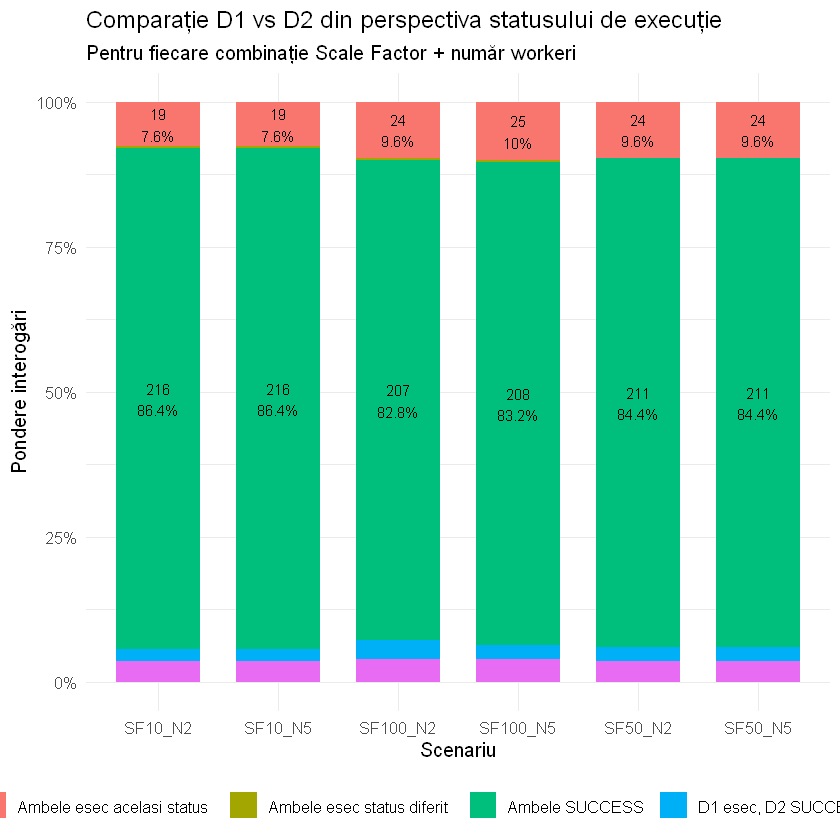

In [43]:
p_d1_d2_status <- d1_d2_status_summary %>%
  mutate(
    scenario_pair = paste0("SF", sf, "_N", workers),
    label = if_else(
      pct_queries >= 5,
      paste0(n_queries, "\n", round(pct_queries, 1), "%"),
      ""
    )
  ) %>%
  ggplot(aes(x = scenario_pair, y = pct_queries / 100, fill = status_comparison_class)) +
  geom_col(width = 0.7) +
  geom_text(
    aes(label = label),
    position = position_stack(vjust = 0.5),
    size = 3.1
  ) +
  scale_y_continuous(labels = percent_format(), limits = c(0, 1)) +
  labs(
    title = "Comparație D1 vs D2 din perspectiva statusului de execuție",
    subtitle = "Pentru fiecare combinație Scale Factor + număr workeri",
    x = "Scenariu",
    y = "Pondere interogări",
    fill = "Clasificare status"
  ) +
  theme_minimal(base_size = 12) +
  theme(legend.position = "bottom")

p_d1_d2_status

ggsave(
  filename = file.path(figures_dir, "plot_d1_vs_d2_status_stacked.png"),
  plot = p_d1_d2_status,
  width = 12,
  height = 7,
  dpi = 300
)

Graficul confirmă vizual că D1 și D2 au un comportament de executabilitate foarte apropiat. În toate combinațiile SF × workers, categoria „Ambele SUCCESS” domină, cu valori între 82,8% și 86,4% dintre interogări.

Categoria „Ambele eșec același status” este a doua ca importanță, cu valori între 7,6% și 10,0%. Acest lucru indică existența unui grup de interogări care eșuează indiferent de strategia de distribuire, ceea ce sugerează limitări legate de execuția distribuită sau de structura SQL, nu doar de alegerea D1/D2.

Diferențele dintre strategii sunt relativ mici, dar vizibile în zona inferioară a graficului. Cazurile în care D1 reușește și D2 eșuează sunt mai frecvente decât invers, ceea ce explică rata de succes ușor mai bună observată anterior pentru D1.

Prin urmare, D2 pare mai avantajoasă pe timp pentru interogările care rulează cu succes, dar D1 este ușor mai stabilă din perspectiva executabilității.

In [47]:
d1_d2_status_transition_matrix <- d1_d2_status_comparison %>%
  count(sf, workers, status_D1, status_D2, name = "n_queries") %>%
  group_by(sf, workers) %>%
  mutate(
    pct_queries = n_queries / sum(n_queries) * 100
  ) %>%
  ungroup() %>%
  arrange(sf, workers, status_D1, status_D2)

write_csv(
  d1_d2_status_transition_matrix,
  file.path(tables_dir, "matrix_d1_vs_d2_status_transitions.csv")
)

d1_d2_status_transition_matrix

sf,workers,status_D1,status_D2,n_queries,pct_queries
<dbl>,<dbl>,<chr>,<chr>,<int>,<dbl>
10,2,CITUS_ARCH_ERROR,CITUS_ARCH_ERROR,19,7.6
10,2,CITUS_ARCH_ERROR,SUCCESS,5,2.0
10,2,SUCCESS,CITUS_ARCH_ERROR,9,3.6
10,2,SUCCESS,SUCCESS,216,86.4
10,2,TIMEOUT_3600,SERVER_CRASH,1,0.4
10,5,CITUS_ARCH_ERROR,CITUS_ARCH_ERROR,19,7.6
10,5,CITUS_ARCH_ERROR,SUCCESS,5,2.0
10,5,SUCCESS,CITUS_ARCH_ERROR,9,3.6
10,5,SUCCESS,SUCCESS,216,86.4


Matricea de tranziții detaliază modul în care se schimbă statusul aceleiași interogări între strategia D1 și strategia D2, pentru aceeași combinație de scale factor și număr de workeri.

Cea mai importantă tranziție este `SUCCESS → SUCCESS`, care domină toate scenariile. Aceasta variază între 82,8% și 86,4%, ceea ce arată că majoritatea interogărilor care rulează cu succes în D1 rulează cu succes și în D2. Prin urmare, cele două strategii au un nucleu comun mare de interogări executabile.

A doua tranziție relevantă este `CITUS_ARCH_ERROR → CITUS_ARCH_ERROR`, constantă la 19 interogări, adică 7,6%, în toate configurațiile. Această stabilitate sugerează că există un set de interogări afectate de limitări arhitecturale Citus indiferent de cheia de distribuire aleasă.

Diferențele dintre D1 și D2 apar mai ales în tranzițiile `SUCCESS → CITUS_ARCH_ERROR` și `CITUS_ARCH_ERROR → SUCCESS`. Prima apare pentru 8–9 interogări pe scenariu, iar a doua pentru 5 interogări pe scenariu. Astfel, D2 recuperează unele interogări care eșuează în D1, dar pierde ușor mai multe interogări care rulau cu succes în D1.

La SF50 și SF100 apar și tranziții legate de `TIMEOUT_3600` și `SERVER_CRASH`, însă acestea au ponderi reduse, de regulă sub 1–2%. Prin urmare, diferența principală dintre D1 și D2 nu este dată de timeout-uri sau crash-uri, ci de comportamentul interogărilor afectate de `CITUS_ARCH_ERROR`.

În ansamblu, matricea confirmă că D1 și D2 sunt apropiate ca executabilitate, dar D1 rămâne ușor mai stabilă, în timp ce D2 poate aduce avantaje de timp pentru interogările care se execută cu succes.

## Comparația dintre N2 și N5 din perspectiva statusului de execuție

In [45]:
n2_n5_status_comparison <- results_master %>%
  filter(
    strategy %in% c("D1", "D2"),
    workers %in% c(2, 5)
  ) %>%
  select(
    sf, strategy, workers, query_id,
    status, error_category, source_file
  ) %>%
  mutate(workers_label = paste0("N", workers)) %>%
  select(-workers) %>%
  pivot_wider(
    names_from = workers_label,
    values_from = c(status, error_category, source_file),
    names_sep = "_"
  ) %>%
  mutate(
    status_transition = paste0(status_N2, " -> ", status_N5),
    status_comparison_class = case_when(
      status_N2 == "SUCCESS" & status_N5 == "SUCCESS" ~ "Ambele au rulat cu succes",
      status_N2 != "SUCCESS" & status_N5 == "SUCCESS" ~ "Imbunatatire: N2 esec, N5 succes",
      status_N2 == "SUCCESS" & status_N5 != "SUCCESS" ~ "Inrautatire: N2 succes, N5 esec",
      status_N2 != "SUCCESS" & status_N5 != "SUCCESS" & status_N2 == status_N5 ~ "Ambele au esuat cu acelasi status",
      status_N2 != "SUCCESS" & status_N5 != "SUCCESS" & status_N2 != status_N5 ~ "Ambele au esuat cu status diferit",
      TRUE ~ "Caz neclasificat"
    )
  ) %>%
  arrange(sf, strategy, query_id)

write_csv(
  n2_n5_status_comparison,
  file.path(tables_dir, "comparison_n2_vs_n5_status.csv")
)

n2_n5_status_summary <- n2_n5_status_comparison %>%
  count(sf, strategy, status_comparison_class, name = "n_queries") %>%
  group_by(sf, strategy) %>%
  mutate(
    total_queries = sum(n_queries),
    pct_queries = n_queries / total_queries * 100
  ) %>%
  ungroup() %>%
  arrange(sf, strategy, desc(n_queries))

write_csv(
  n2_n5_status_summary,
  file.path(tables_dir, "summary_n2_vs_n5_status.csv")
)

n2_n5_status_summary

sf,strategy,status_comparison_class,n_queries,total_queries,pct_queries
<dbl>,<chr>,<chr>,<int>,<int>,<dbl>
10,D1,Ambele au rulat cu succes,225,250,90.0
10,D1,Ambele au esuat cu acelasi status,25,250,10.0
10,D2,Ambele au rulat cu succes,221,250,88.4
10,D2,Ambele au esuat cu acelasi status,29,250,11.6
50,D1,Ambele au rulat cu succes,220,250,88.0
50,D1,Ambele au esuat cu acelasi status,30,250,12.0
50,D2,Ambele au rulat cu succes,217,250,86.8
50,D2,Ambele au esuat cu acelasi status,33,250,13.2
100,D1,Ambele au rulat cu succes,217,250,86.8


Tabelul arată că scalarea de la 2 la 5 workeri modifică într-o măsură foarte mică executabilitatea interogărilor. În majoritatea cazurilor, interogările au același status în N2 și N5.

Categoria „Ambele au rulat cu succes” este dominantă în toate combinațiile, cu valori între 85,6% și 90,0%. La SF10_D1, 225 de interogări rulează cu succes atât în N2, cât și în N5, iar la SF10_D2 sunt 221. La SF50, valorile sunt 220 pentru D1 și 217 pentru D2. La SF100, acestea scad ușor la 217 pentru D1 și 214 pentru D2.

Categoria „Ambele au eșuat cu același status” crește odată cu scale factor-ul: de la 25–29 de interogări la SF10, la 30–33 la SF50 și 32–35 la SF100. Acest lucru sugerează că, la volume mai mari de date, există mai multe interogări care rămân problematice indiferent dacă sunt folosiți 2 sau 5 workeri.

Cazurile în care scalarea schimbă statusul sunt foarte rare. La SF100_D1 apare o singură îmbunătățire, unde N2 eșuează și N5 reușește, iar la SF100_D2 apare un singur caz invers, unde N2 reușește și N5 eșuează. Prin urmare, din perspectiva executabilității, adăugarea workerilor nu schimbă substanțial rezultatul execuției.

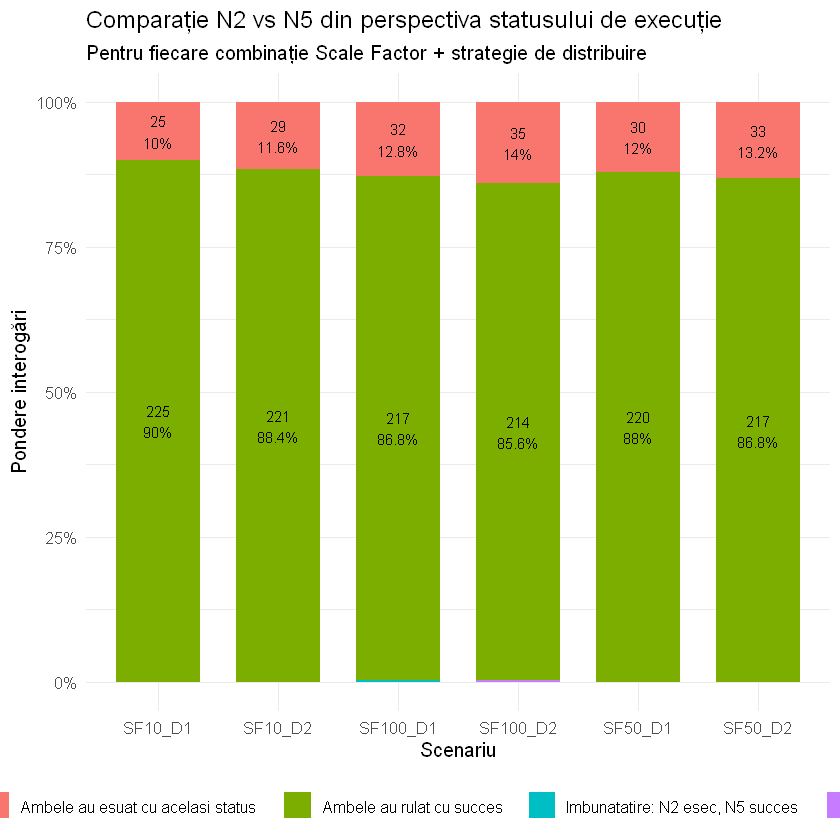

In [46]:
p_n2_n5_status <- n2_n5_status_summary %>%
  mutate(
    scenario_pair = paste0("SF", sf, "_", strategy),
    label = if_else(
      pct_queries >= 5,
      paste0(n_queries, "\n", round(pct_queries, 1), "%"),
      ""
    )
  ) %>%
  ggplot(aes(x = scenario_pair, y = pct_queries / 100, fill = status_comparison_class)) +
  geom_col(width = 0.7) +
  geom_text(
    aes(label = label),
    position = position_stack(vjust = 0.5),
    size = 3.1
  ) +
  scale_y_continuous(labels = percent_format(), limits = c(0, 1)) +
  labs(
    title = "Comparație N2 vs N5 din perspectiva statusului de execuție",
    subtitle = "Pentru fiecare combinație Scale Factor + strategie de distribuire",
    x = "Scenariu",
    y = "Pondere interogări",
    fill = "Clasificare status"
  ) +
  theme_minimal(base_size = 12) +
  theme(legend.position = "bottom")

p_n2_n5_status

ggsave(
  filename = file.path(figures_dir, "plot_n2_vs_n5_status_stacked.png"),
  plot = p_n2_n5_status,
  width = 12,
  height = 7,
  dpi = 300
)

# Partea II — Caracteristicile structurale ale interogărilor SQL


Încărcarea setului de date pentru metadatele din setul de interogări:

In [7]:
metadata_file <- file.path(base_dir, "R", "query_metadata.csv")

In [8]:
query_metadata <- read_csv(metadata_file, show_col_types = FALSE) %>%
  clean_names()

glimpse(query_metadata)

Rows: 250
Columns: 31
$ query_id            <chr> "Q001", "Q002", "Q003", "Q004", "Q005", "Q006", "Q…
$ n_tables            <dbl> 3, 3, 4, 6, 4, 4, 2, 3, 3, 3, 3, 4, 4, 4, 3, 4, 3,…
$ n_joins             <dbl> 2, 2, 3, 5, 3, 3, 1, 2, 3, 3, 2, 3, 2, 3, 2, 3, 4,…
$ n_subqueries        <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 1, 2, 0, 0, 0, 1,…
$ n_ctes              <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,…
$ n_inner_joins       <dbl> 2, 2, 3, 5, 2, 3, 1, 2, 3, 3, 2, 3, 2, 3, 2, 3, 4,…
$ n_left_joins        <dbl> 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,…
$ n_right_joins       <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,…
$ n_full_joins        <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,…
$ n_cross_joins       <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,…
$ has_group_by        <lgl> TRUE, TRUE, TRUE, TRUE, TRUE, TRUE, TRUE, TRUE, TR…
$ has_order_by        <lgl> TRUE, TRUE, TRUE, TRUE, TRUE, TRUE, TRUE, TRUE, TR…
$ has_limit       

Setul de metadate include 31 de variabile care descriu structura SQL a interogărilor: numărul de tabele, join-uri, subinterogări, CTE-uri, agregări, predicate, operatori și indicatori binari pentru clauze precum `GROUP BY`, `ORDER BY`, `HAVING`, `WINDOW`, `UNION`, `ROLLUP` sau `CUBE`.

In [9]:
n_queries <- nrow(query_metadata)
n_queries

[1] 250

In [10]:
nr_distinct_queries<-distinct(query_metadata,query_id)
nrow(nr_distinct_queries)

[1] 250

In [11]:
missing_summary <- query_metadata %>%
  summarise(across(everything(), ~ sum(is.na(.)))) %>%
  pivot_longer(everything(), names_to = "variable", values_to = "n_missing") %>%
  mutate(percent_missing = round(n_missing / n_queries * 100, 2)) %>%
  arrange(desc(n_missing))

print(missing_summary, n = Inf)


# A tibble: 31 × 3
   variable            n_missing percent_missing
   <chr>                   <int>           <dbl>
 1 having_operators          165            66  
 2 aggregate_types            27            10.8
 3 where_operators            12             4.8
 4 query_id                    0             0  
 5 n_tables                    0             0  
 6 n_joins                     0             0  
 7 n_subqueries                0             0  
 8 n_ctes                      0             0  
 9 n_inner_joins               0             0  
10 n_left_joins                0             0  
11 n_right_joins               0             0  
12 n_full_joins                0             0  
13 n_cross_joins               0             0  
14 has_group_by                0             0  
15 has_order_by                0             0  
16 has_limit                   0             0  
17 has_distinct                0             0  
18 has_having                  0             0  
1

Verificarea valorilor lipsă arată că majoritatea variabilelor din `query_metadata` sunt complete. Valorile lipsă apar doar în câmpurile descriptive pentru operatori/tipuri agregate.

Cele mai multe valori lipsă sunt la `having_operators`, deoarece numai interogările care conțin clauza `HAVING` pot avea operatori asociați acesteia. Similar, lipsurile din `aggregate_types` și `where_operators` apar în cazurile în care interogarea nu conține agregări sau predicate `WHERE` relevante.

Prin urmare, aceste valori lipsă nu indică probleme de calitate a datelor, ci absența logică a unor construcții SQL în anumite interogări.

In [12]:
binary_distribution <- query_metadata %>%
  select(starts_with("has_")) %>%
  summarise(across(everything(), ~ sum(as.logical(.)))) %>%
  pivot_longer(everything(), names_to = "variable", values_to = "n_yes") %>%
  mutate(
    n_no = n_queries - n_yes,
    percent_yes = round(n_yes / n_queries * 100, 1)
  ) %>%
  arrange(desc(percent_yes))

write_csv(
  binary_distribution,
  file.path(tables_dir, "query_metadata_binary_distribution_initial.csv")
)

print(binary_distribution, n = Inf)

# A tibble: 14 × 4
   variable       n_yes  n_no percent_yes
   <chr>          <int> <int>       <dbl>
 1 has_group_by     223    27        89.2
 2 has_aggregates   223    27        89.2
 3 has_order_by     210    40        84  
 4 has_having        85   165        34  
 5 has_distinct      57   193        22.8
 6 has_limit         52   198        20.8
 7 has_window        39   211        15.6
 8 has_case          36   214        14.4
 9 has_union         11   239         4.4
10 has_intersect      7   243         2.8
11 has_except         6   244         2.4
12 has_rollup         2   248         0.8
13 has_grouping       1   249         0.4
14 has_cube           1   249         0.4


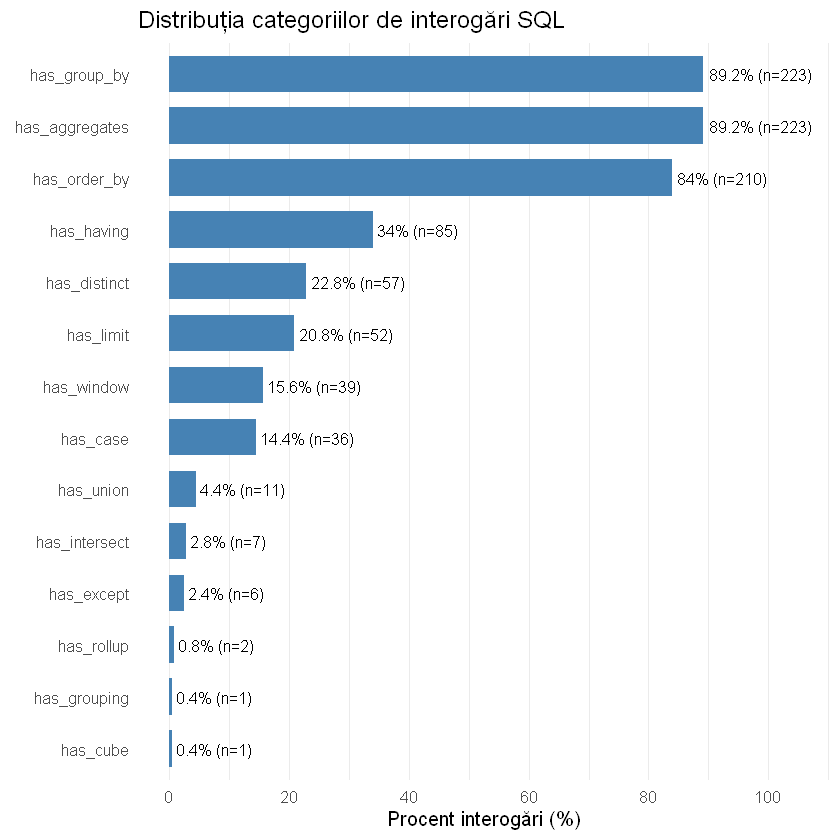

In [13]:
p_binary <- binary_distribution %>%
  mutate(variable = fct_reorder(variable, percent_yes)) %>%
  ggplot(aes(x = variable, y = percent_yes)) +
    geom_col(fill = "steelblue", width = 0.7) +
    geom_text(
      aes(label = paste0(percent_yes, "% (n=", n_yes, ")")),
      hjust = -0.05, size = 3.3
    ) +
    coord_flip() +
    scale_y_continuous(limits = c(0, 105), breaks = seq(0, 100, 20)) +
    labs(
      title = "Distribuția categoriilor de interogări SQL",
      x = NULL,
      y = "Procent interogări (%)"
    ) +
    theme_minimal(base_size = 12) +
    theme(panel.grid.major.y = element_blank())
ggsave(
  filename = file.path(figures_dir, "plot_query_metadata_binary_distribution.png"),
  plot = p_binary,
  width = 10,
  height = 7,
  dpi = 300
)

p_binary

Cele mai frecvente caracteristici structurale sunt `has_group_by` și `has_aggregates`, prezente în 89,2% dintre interogări, urmate de `has_order_by`, prezent în 84,0%. Acest lucru confirmă caracterul analitic al workload-ului TPC-DS, orientat spre agregări, grupări și sortări.

Caracteristici precum `has_having`, `has_distinct`, `has_limit` și `has_window` apar mai rar, dar suficient de frecvent pentru a fi analizate descriptiv în raport cu performanța și executabilitatea.

În schimb, construcții precum `has_rollup`, `has_grouping` și `has_cube` apar foarte rar, sub 1%, deci nu pot susține concluzii generale, dar pot fi relevante punctual pentru anumite erori arhitecturale.

In [14]:
shapiro_w <- function(x) {
  x <- x[!is.na(x)]
  if (length(x) < 3 || length(unique(x)) < 2) return(NA_real_)
  as.numeric(shapiro.test(x)$statistic)
}

shapiro_p <- function(x) {
  x <- x[!is.na(x)]
  if (length(x) < 3 || length(unique(x)) < 2) return(NA_real_)
  as.numeric(shapiro.test(x)$p.value)
}

numeric_descriptive <- query_metadata %>%
  select(where(is.numeric)) %>%
  pivot_longer(everything(), names_to = "variable", values_to = "value") %>%
  group_by(variable) %>%
  summarise(
    n        = sum(!is.na(value)),
    min      = min(value, na.rm = TRUE),
    q1       = quantile(value, 0.25, na.rm = TRUE),
    median   = median(value, na.rm = TRUE),
    q3       = quantile(value, 0.75, na.rm = TRUE),
    max      = max(value, na.rm = TRUE),
    mean     = round(mean(value, na.rm = TRUE), 2),
    sd       = round(sd(value, na.rm = TRUE), 2),
    sw_W     = round(shapiro_w(value), 3),
    sw_pval  = signif(shapiro_p(value), 3),
    .groups  = "drop"
  ) %>%
  arrange(variable)

write_csv(
  numeric_descriptive,
  file.path(tables_dir, "query_metadata_numeric_descriptive.csv")
)

numeric_descriptive

variable,n,min,q1,median,q3,max,mean,sd,sw_W,sw_pval
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
n_aggregate_calls,250,0,1.25,3,4,15,2.83,2.17,0.864,4.51e-14
n_aggregate_types,250,0,1.00,1,2,5,1.45,0.90,0.861,3.02e-14
n_cross_joins,250,0,0.00,0,0,1,0.01,0.11,0.083,6.15e-33
n_ctes,250,0,0.00,0,0,4,0.35,0.69,0.554,7.82e-25
n_full_joins,250,0,0.00,0,0,1,0.01,0.11,0.083,6.15e-33
n_having_predicates,250,0,0.00,0,1,7,0.51,0.99,0.551,6.90e-25
n_inner_joins,250,0,2.00,3,4,9,2.91,1.50,0.928,1.03e-09
n_joins,250,0,2.00,3,4,12,3.19,1.59,0.881,4.45e-13
n_left_joins,250,0,0.00,0,0,3,0.25,0.59,0.472,1.27e-26


Tabelul arată că interogările au, în general, o structură analitică complexă: mediana este de 4 tabele, 3 join-uri, 3 predicate `WHERE` și 3 apeluri agregate per query.

Variabile precum `n_tables`, `n_joins`, `n_inner_joins`, `n_where_predicates` și `n_aggregate_calls` au variație suficientă pentru a fi păstrate numeric. În schimb, variabilele dominate de zero, precum `n_ctes`, `n_subqueries`, `n_left_joins`, `n_right_joins`, `n_full_joins` și `n_cross_joins`, sunt mai potrivite pentru recodare binară de tip prezență/absență.

Valorile p foarte mici ale testului Shapiro-Wilk indică distribuții nenormale, ceea ce justifică folosirea metodelor neparametrice în analizele următoare.

In [15]:
numeric_long <- query_metadata %>%
  select(where(is.numeric)) %>%
  mutate(row_id = row_number()) %>%
  pivot_longer(-row_id, names_to = "variable", values_to = "value")

variable_cardinality <- numeric_long %>%
  group_by(variable) %>%
  summarise(n_distinct_values = n_distinct(value), .groups = "drop") %>%
  arrange(n_distinct_values)

write_csv(
  variable_cardinality,
  file.path(tables_dir, "query_metadata_numeric_cardinality.csv")
)

variable_cardinality

variable,n_distinct_values
<chr>,<int>
n_cross_joins,2
n_full_joins,2
n_right_joins,2
n_ctes,4
n_left_joins,4
n_subqueries,5
n_aggregate_types,6
n_having_predicates,7
n_tables,8


Tabelul arată câte valori distincte are fiecare variabilă numerică structurală. Variabile precum `n_cross_joins`, `n_full_joins` și `n_right_joins` au foarte puține valori distincte, ceea ce indică faptul că aceste construcții apar rar în setul de interogări analizat.

În schimb, variabile precum `n_tables`, `n_inner_joins`, `n_joins`, `n_where_predicates` și `n_aggregate_calls` au o variabilitate mai mare și sunt mai potrivite pentru analize numerice ulterioare.

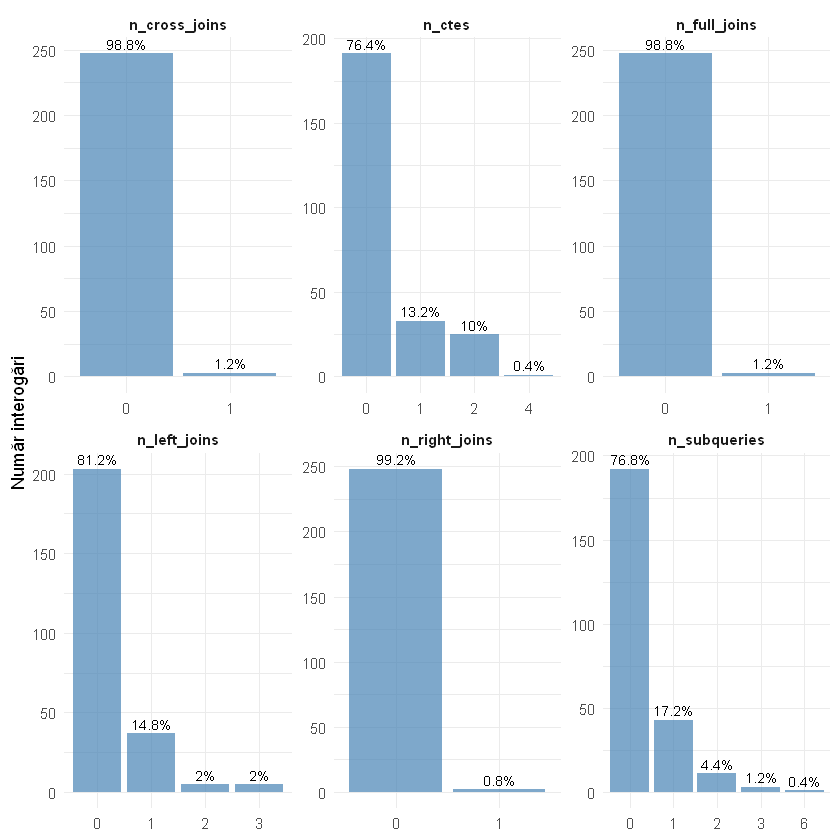

In [17]:
low_card_vars <- variable_cardinality %>%
  filter(n_distinct_values <= 5) %>%
  pull(variable)

p_low_card <- numeric_long %>%
  filter(variable %in% low_card_vars) %>%
  group_by(variable, value) %>%
  summarise(n = n(), .groups = "drop") %>%
  mutate(percent = round(n / n_queries * 100, 1)) %>%
  ggplot(aes(x = factor(value), y = n)) +
    geom_col(fill = "steelblue", alpha = 0.7) +
    geom_text(aes(label = paste0(percent, "%")),
              vjust = -0.4, size = 3) +
    facet_wrap(~ variable, scales = "free", ncol = 3) +
    labs(x = NULL, y = "Număr interogări") +
    theme_minimal(base_size = 11) +
    theme(strip.text = element_text(face = "bold"))

ggsave(
  filename = file.path(figures_dir, "plot_query_metadata_low_cardinality.png"),
  plot = p_low_card,
  width = 11,
  height = 7,
  dpi = 300
)

p_low_card

Graficul arată că aceste variabile au distribuții puternic dezechilibrate, fiind dominate de valoarea 0. `n_cross_joins`, `n_full_joins` și `n_right_joins` apar foarte rar, în peste 98% dintre interogări având valoarea 0.

Și pentru `n_ctes`, `n_left_joins` și `n_subqueries`, majoritatea interogărilor nu conțin aceste construcții, dar există un număr mai vizibil de cazuri în care apar. De exemplu, CTE-urile lipsesc în 76,4% dintre interogări, iar subinterogările lipsesc în 76,8%.

Prin urmare, aceste variabile trebuie interpretate cu prudență: ele pot fi relevante pentru anumite query-uri problematice, dar nu descriu comportamentul general al întregului workload.

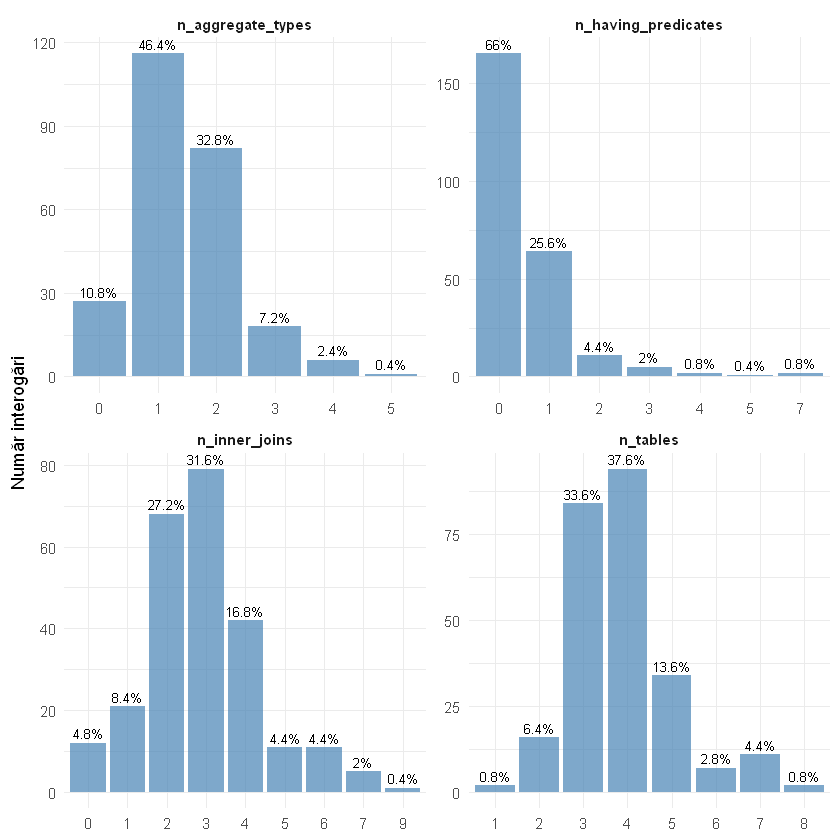

In [18]:
med_card_vars <- variable_cardinality %>%
  filter(n_distinct_values > 5, n_distinct_values <= 10) %>%
  pull(variable)

p_med_card <- numeric_long %>%
  filter(variable %in% med_card_vars) %>%
  group_by(variable, value) %>%
  summarise(n = n(), .groups = "drop") %>%
  mutate(percent = round(n / n_queries * 100, 1)) %>%
  ggplot(aes(x = factor(value), y = n)) +
    geom_col(fill = "steelblue", alpha = 0.7) +
    geom_text(aes(label = paste0(percent, "%")),
              vjust = -0.4, size = 2.8) +
    facet_wrap(~ variable, scales = "free", ncol = 2) +
    labs(x = NULL, y = "Număr interogări") +
    theme_minimal(base_size = 11) +
    theme(strip.text = element_text(face = "bold"))

ggsave(
  filename = file.path(figures_dir, "plot_query_metadata_medium_cardinality.png"),
  plot = p_med_card,
  width = 11,
  height = 7,
  dpi = 300
)

p_med_card

Aceste variabile au o distribuție mai variată și descriu mai bine complexitatea generală a interogărilor. Majoritatea query-urilor folosesc 3–4 tabele și 2–4 inner join-uri, ceea ce confirmă caracterul relațional și analitic al workload-ului.

Pentru agregări, cele mai multe interogări folosesc 1–2 tipuri de funcții agregate, iar numai puține ajung la 4–5 tipuri. Predicatele `HAVING` sunt absente în 66,0% dintre interogări, dar apar cu 1–2 condiții într-un segment relevant al workload-ului.

Aceste variabile sunt mai potrivite pentru analize cantitative ulterioare, deoarece au suficientă variație pentru a fi comparate cu timpul de execuție și statusul.

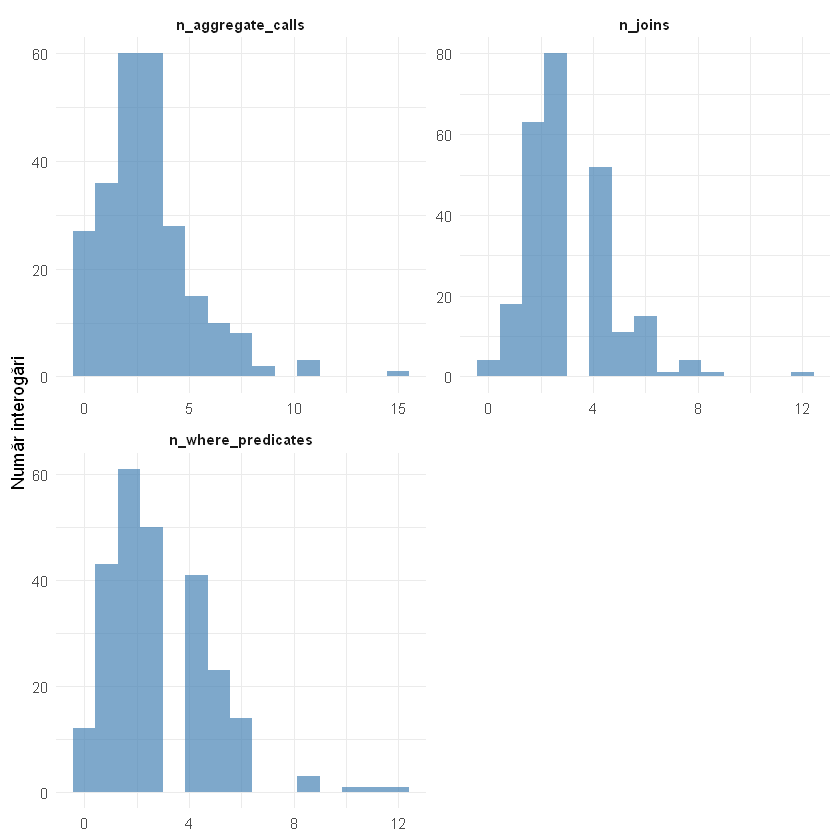

In [19]:
high_card_vars <- variable_cardinality %>%
  filter(n_distinct_values > 10) %>%
  pull(variable)

if (length(high_card_vars) > 0) {
  p_high_card <- numeric_long %>%
    filter(variable %in% high_card_vars) %>%
    ggplot(aes(x = value)) +
      geom_histogram(bins = 15, fill = "steelblue", alpha = 0.7) +
      facet_wrap(~ variable, scales = "free", ncol = 2) +
      labs(x = NULL, y = "Număr interogări") +
      theme_minimal(base_size = 11) +
      theme(strip.text = element_text(face = "bold"))

    ggsave(
    filename = file.path(figures_dir, "plot_query_metadata_high_cardinality.png"),
    plot = p_high_card,
    width = 11,
    height = 7,
    dpi = 300
  )
  p_high_card
} else {
  cat("Nicio variabilă numerică cu peste 10 valori distincte.\n")
}

Variabilele cu peste 10 valori distincte sunt `n_aggregate_calls`, `n_joins` și `n_where_predicates`. Acestea surprind dimensiuni importante ale complexității interogărilor: numărul de agregări, numărul total de join-uri și numărul de predicate de filtrare.

Distribuțiile sunt asimetrice, cu majoritatea valorilor concentrate în zona joasă-medie și câteva interogări cu valori mult mai ridicate. Aceste variabile sunt relevante pentru analiza RQ4, deoarece pot fi comparate direct cu timpul de execuție și cu probabilitatea de succes/eșec.

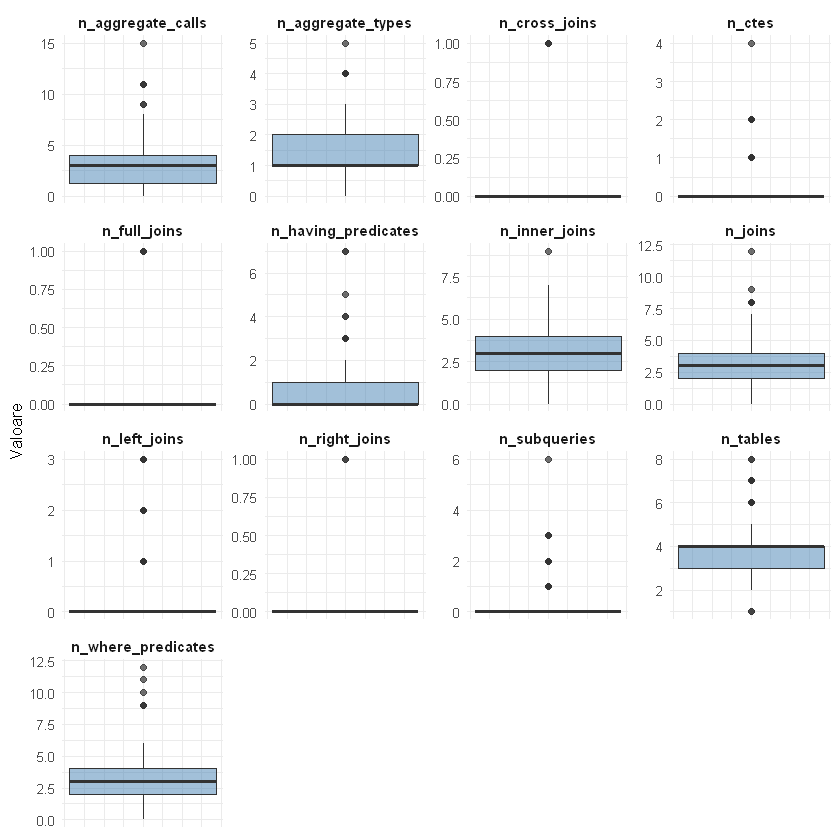

In [20]:
p_boxplots <- numeric_long %>%
  ggplot(aes(y = value)) +
    geom_boxplot(fill = "steelblue", alpha = 0.5, outlier.alpha = 0.7) +
    facet_wrap(~ variable, scales = "free", ncol = 4) +
    labs(x = NULL, y = "Valoare") +
    theme_minimal(base_size = 10) +
    theme(
      axis.text.x = element_blank(),
      axis.ticks.x = element_blank(),
      strip.text = element_text(face = "bold", size = 9)
    )

ggsave(
  filename = file.path(figures_dir, "plot_query_metadata_numeric_boxplots.png"),
  plot = p_boxplots,
  width = 12,
  height = 8,
  dpi = 300
)

p_boxplots

Boxplot-urile confirmă că variabilele structurale au distribuții neuniforme. Unele variabile, precum `n_tables`, `n_inner_joins`, `n_joins`, `n_where_predicates` și `n_aggregate_calls`, au o variație clară între interogări și pot fi folosite ca indicatori numerici ai complexității SQL.

În schimb, variabile precum `n_cross_joins`, `n_full_joins`, `n_right_joins`, `n_left_joins`, `n_ctes` și `n_subqueries` sunt concentrate în jurul valorii 0, cu puține valori extreme. Acestea indică apariții punctuale ale unor construcții SQL specifice, nu caracteristici generale ale workload-ului.

Prin urmare, pentru RQ4, analiza trebuie să distingă între variabile frecvente, care pot explica tendințe generale de performanță, și variabile rare, care pot fi relevante mai ales pentru cazuri problematice sau erori specifice.

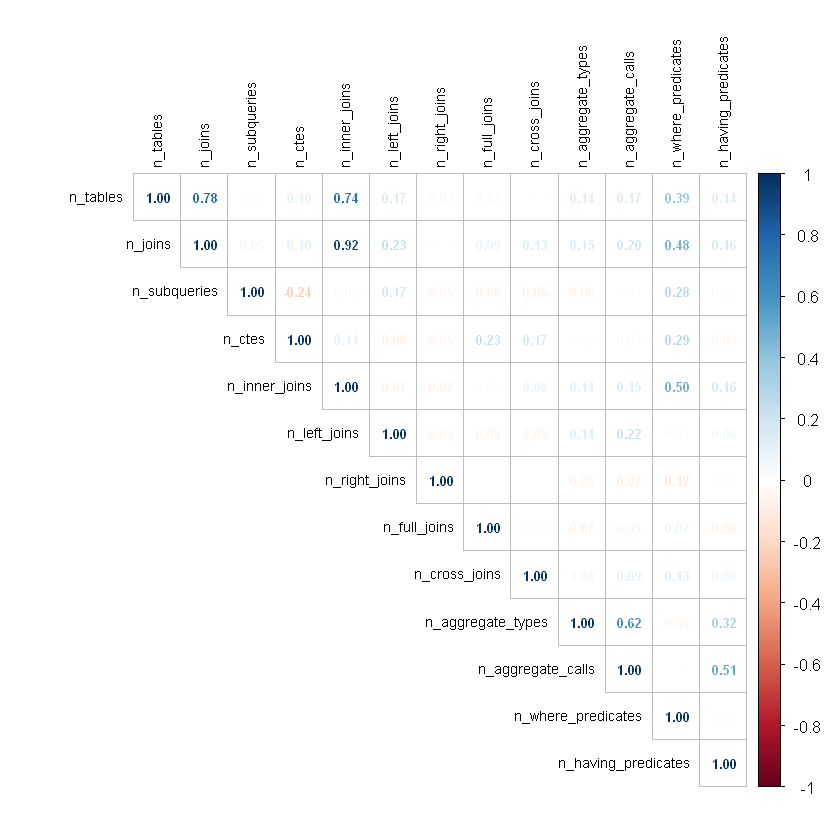

In [21]:
corr_matrix <- query_metadata %>%
  select(where(is.numeric)) %>%
  cor(method = "spearman", use = "pairwise.complete.obs")

corrplot::corrplot(
  corr_matrix,
  method = "number",
  type = "upper",
  tl.cex = 0.7,
  number.cex = 0.65,
  tl.col = "black"
)

In [22]:
corr_matrix_export <- as.data.frame(corr_matrix) %>%
  rownames_to_column("variable")

write_csv(
  corr_matrix_export,
  file.path(tables_dir, "query_metadata_spearman_correlation_matrix.csv")
)

Matricea de corelație Spearman arată asocieri puternice între unele variabile structurale, ceea ce este așteptat. De exemplu, `n_joins` este foarte corelat cu `n_inner_joins` (0,92), iar `n_tables` este corelat cu `n_joins` (0,78) și `n_inner_joins` (0,74). Aceste relații indică faptul că interogările care folosesc mai multe tabele tind să includă și mai multe join-uri.

Există și o corelație moderată între `n_aggregate_types` și `n_aggregate_calls` (0,62), ceea ce arată că interogările cu mai multe apeluri agregate tind să folosească și tipuri mai variate de agregări.

Aceste rezultate sunt utile pentru modelele ulterioare, deoarece arată posibile relații de coliniaritate între variabilele explicative. În interpretarea importanței variabilelor, `n_tables`, `n_joins` și `n_inner_joins` trebuie analizate cu atenție, deoarece măsoară dimensiuni apropiate ale complexității interogărilor.

## Recodarea variabilelor numerice rare în indicatori binari

Pe baza statisticilor descriptive și a distribuțiilor observate, unele variabile structurale sunt dominate de valoarea 0. În aceste cazuri, numărul exact de apariții este mai puțin informativ pentru analiza descriptivă decât simpla prezență sau absență a construcției SQL.

Prin urmare, variabile precum `n_ctes`, `n_subqueries`, `n_left_joins`, `n_right_joins`, `n_full_joins` și `n_cross_joins` sunt recodate suplimentar în indicatori binari de tip `yes/no`. Forma numerică originală este păstrată, iar noile variabile vor fi utilizate în analiză pentru a compara performanța și executabilitatea interogărilor în funcție de prezența acestor construcții.

In [24]:
query_metadata <- query_metadata %>%
  mutate(
    has_cte = factor(if_else(n_ctes > 0, "yes", "no"), levels = c("no", "yes")),
    has_subqueries = factor(if_else(n_subqueries > 0, "yes", "no"), levels = c("no", "yes")),
    has_left_join = factor(if_else(n_left_joins > 0, "yes", "no"), levels = c("no", "yes")),
    has_right_join = factor(if_else(n_right_joins > 0, "yes", "no"), levels = c("no", "yes")),
    has_full_join = factor(if_else(n_full_joins > 0, "yes", "no"), levels = c("no", "yes")),
    has_cross_join = factor(if_else(n_cross_joins > 0, "yes", "no"), levels = c("no", "yes"))
  )

glimpse(query_metadata)

Rows: 250
Columns: 37
$ query_id            <chr> "Q001", "Q002", "Q003", "Q004", "Q005", "Q006", "Q…
$ n_tables            <dbl> 3, 3, 4, 6, 4, 4, 2, 3, 3, 3, 3, 4, 4, 4, 3, 4, 3,…
$ n_joins             <dbl> 2, 2, 3, 5, 3, 3, 1, 2, 3, 3, 2, 3, 2, 3, 2, 3, 4,…
$ n_subqueries        <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 1, 2, 0, 0, 0, 1,…
$ n_ctes              <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,…
$ n_inner_joins       <dbl> 2, 2, 3, 5, 2, 3, 1, 2, 3, 3, 2, 3, 2, 3, 2, 3, 4,…
$ n_left_joins        <dbl> 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,…
$ n_right_joins       <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,…
$ n_full_joins        <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,…
$ n_cross_joins       <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,…
$ has_group_by        <lgl> TRUE, TRUE, TRUE, TRUE, TRUE, TRUE, TRUE, TRUE, TR…
$ has_order_by        <lgl> TRUE, TRUE, TRUE, TRUE, TRUE, TRUE, TRUE, TRUE, TR…
$ has_limit       

In [25]:
# Verificarea distribuției noilor variabile binare 

new_binaries <- c("has_cte", "has_subqueries", "has_left_join", 
                  "has_right_join", "has_full_join", "has_cross_join")

new_binary_distribution <- query_metadata %>%
  select(all_of(new_binaries)) %>%
  pivot_longer(everything(), names_to = "variable", values_to = "value") %>%
  count(variable, value, name = "n") %>%
  group_by(variable) %>%
  mutate(percent = round(n / sum(n) * 100, 1)) %>%
  ungroup() %>%
  arrange(variable, desc(value))

write_csv(
  new_binary_distribution,
  file.path(tables_dir, "query_metadata_new_binary_distribution.csv")
)

new_binary_distribution

variable,value,n,percent
<chr>,<fct>,<int>,<dbl>
has_cross_join,yes,3,1.2
has_cross_join,no,247,98.8
has_cte,yes,59,23.6
has_cte,no,191,76.4
has_full_join,yes,3,1.2
has_full_join,no,247,98.8
has_left_join,yes,47,18.8
has_left_join,no,203,81.2
has_right_join,yes,2,0.8


Binarizarea variabilelor de mai sus confirmă distribuțiile observate anterior: aceste construcții SQL apar relativ rar în setul de interogări. CTE-urile apar în 59 de interogări, adică 23,6%, iar subinterogările în 58 de interogări, adică 23,2%. Join-urile de tip `LEFT` apar în 18,8% dintre interogări.

În schimb, `RIGHT JOIN`, `FULL JOIN` și `CROSS JOIN` sunt foarte rare, fiecare apărând în cel mult 1,2% dintre interogări.

## Unificare variabile has_* ca factori cu nivelurile c("no", "yes") 
Variabilele has_* existente ca TRUE/FALSE și cele recodate ca no/yes sunt aduse la același format pentru tabele, grafice și teste de asociere.

In [26]:
query_metadata <- query_metadata %>%
  mutate(
    across(
      starts_with("has_"),
      ~ factor(
        case_when(
          tolower(as.character(.x)) %in% c("true", "yes")  ~ "yes",
          tolower(as.character(.x)) %in% c("false", "no")  ~ "no",
          TRUE ~ NA_character_
        ),
        levels = c("no", "yes")
      )
    )
  )

glimpse(query_metadata)

Rows: 250
Columns: 37
$ query_id            <chr> "Q001", "Q002", "Q003", "Q004", "Q005", "Q006", "Q…
$ n_tables            <dbl> 3, 3, 4, 6, 4, 4, 2, 3, 3, 3, 3, 4, 4, 4, 3, 4, 3,…
$ n_joins             <dbl> 2, 2, 3, 5, 3, 3, 1, 2, 3, 3, 2, 3, 2, 3, 2, 3, 4,…
$ n_subqueries        <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 1, 2, 0, 0, 0, 1,…
$ n_ctes              <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,…
$ n_inner_joins       <dbl> 2, 2, 3, 5, 2, 3, 1, 2, 3, 3, 2, 3, 2, 3, 2, 3, 4,…
$ n_left_joins        <dbl> 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,…
$ n_right_joins       <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,…
$ n_full_joins        <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,…
$ n_cross_joins       <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,…
$ has_group_by        <fct> yes, yes, yes, yes, yes, yes, yes, yes, yes, yes, …
$ has_order_by        <fct> yes, yes, yes, yes, yes, yes, yes, yes, yes, yes, …
$ has_limit       

In [27]:
query_metadata %>%
  select(starts_with("has_")) %>%
  summarise(across(everything(), ~ sum(is.na(.x))))

has_group_by,has_order_by,has_limit,has_distinct,has_having,has_case,has_aggregates,has_window,has_union,has_except,has_intersect,has_grouping,has_rollup,has_cube,has_cte,has_subqueries,has_left_join,has_right_join,has_full_join,has_cross_join
<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [28]:
write_csv(query_metadata, file.path(base_dir, "R", "query_metadata_unified.csv"))
saveRDS(query_metadata, file.path(base_dir, "R", "query_metadata_unified.rds"))

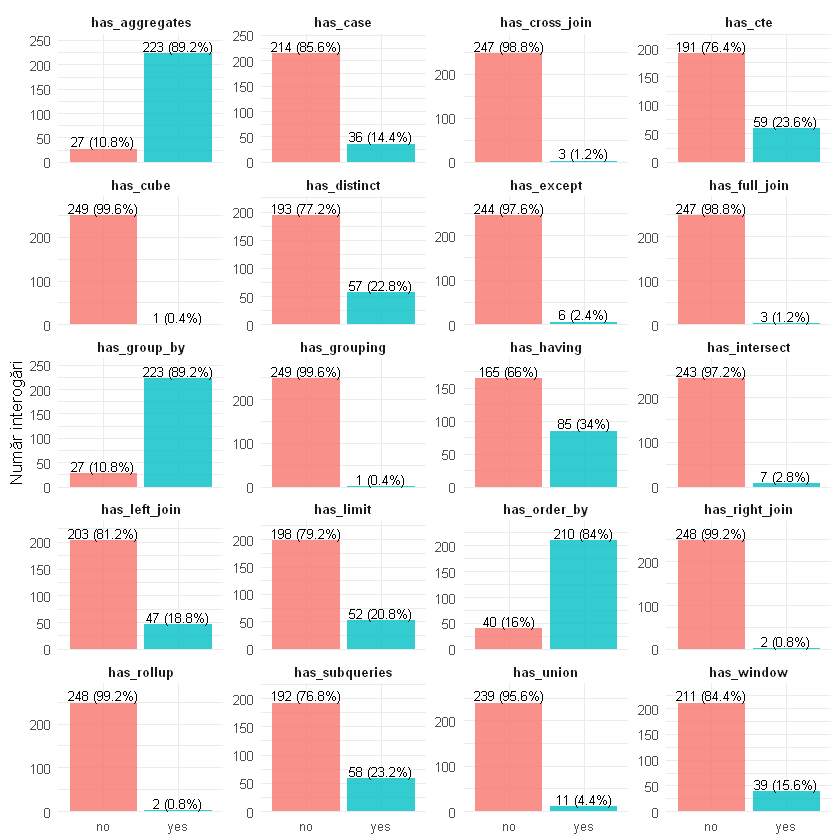

In [30]:
p_has_distribution <- has_long %>%
  count(variable, value) %>%
  group_by(variable) %>%
  mutate(percent = round(n / sum(n) * 100, 1)) %>%
  ungroup() %>%
  ggplot(aes(x = value, y = n, fill = value)) +
  geom_col(alpha = 0.8) +
  geom_text(
    aes(label = paste0(n, " (", percent, "%)")),
    vjust = -0.2,
    size = 2.7
  ) +
  facet_wrap(~ variable, scales = "free_y", ncol = 4) +
  scale_y_continuous(expand = expansion(mult = c(0, 0.18))) +
  labs(
    x = NULL,
    y = "Număr interogări",
    fill = NULL
  ) +
  theme_minimal(base_size = 10) +
  theme(
    legend.position = "none",
    strip.text = element_text(face = "bold"),
    axis.text.x = element_text(size = 8)
  )

p_has_distribution

In [31]:
ggsave(
  filename = file.path(figures_dir, "plot_query_metadata_has_distribution.png"),
  plot = p_has_distribution,
  width = 13,
  height = 10,
  dpi = 300
)

Graficul prezintă distribuția variabilelor binare `has_*`. Se observă că anumite caracteristici sunt foarte frecvente în workload: `has_group_by` și `has_aggregates` apar în 223 de interogări (89,2%), iar `has_order_by` apare în 210 interogări (84,0%). Acest rezultat confirmă caracterul analitic al interogărilor TPC-DS, orientate către agregări, grupări și sortări.

Alte construcții apar cu frecvență intermediară. De exemplu, `has_having` este prezentă în 85 de interogări (34,0%), `has_subqueries` în 58 de interogări (23,2%), `has_distinct` în 57 de interogări (22,8%), iar `has_limit` în 52 de interogări (20,8%). 

În schimb, unele construcții SQL sunt foarte rare: `has_cube`, `has_grouping`, `has_rollup`, `has_full_join`, `has_cross_join` și `has_right_join` apar în mai puțin de 2% dintre interogări.

În ansamblu, distribuția variabilelor `has_*` arată că workload-ul este dominat de interogări analitice cu agregări, grupări și sortări, în timp ce construcțiile SQL mai speciale apar rar și vor necesita o interpretare separată în analiza structurală.

## Consolidarea datasetului df_master

Se construiește datasetul consolidat prin `inner_join` între `results_master` și `query_metadata`.

A fost adăugată variabila `architecture` cu două niveluri (`baseline` și `distributed`) pentru a facilita comparațiile dintre execuția mononod și cea distribuită. 

In [32]:
df_master <- results_master %>%
  inner_join(query_metadata, by = "query_id") %>%
  mutate(
    architecture = factor(
      if_else(strategy == "baseline", "baseline", "distributed"),
      levels = c("baseline", "distributed")
    )
  )

glimpse(df_master)

Rows: 3,750
Columns: 52
$ scenario            <chr> "SF10_N0", "SF10_N0", "SF10_N0", "SF10_N0", "SF10_…
$ sf                  <dbl> 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10…
$ workers             <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,…
$ strategy            <chr> "baseline", "baseline", "baseline", "baseline", "b…
$ query_no            <dbl> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15,…
$ query_id            <chr> "Q001", "Q002", "Q003", "Q004", "Q005", "Q006", "Q…
$ status              <chr> "SUCCESS", "SUCCESS", "SUCCESS", "SUCCESS", "SUCCE…
$ error_category      <chr> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA…
$ elapsed_ms          <dbl> 14165, 6954, 11010, 12679, 29054, 114241, 1416, 36…
$ elapsed_sec         <dbl> 14.165, 6.954, 11.010, 12.679, 29.054, 114.241, 1.…
$ success             <lgl> TRUE, TRUE, TRUE, TRUE, TRUE, TRUE, TRUE, TRUE, TR…
$ response_code       <chr> "200", "200", "200", "200", "200", "200", "200", "…
$ response_messa

In [33]:
df_master_check <- df_master %>%
  summarise(
    total_observatii = n(),
    total_scenarii = n_distinct(scenario),
    total_query_ids = n_distinct(query_id),
    total_architectures = n_distinct(architecture)
  )

df_master_check

total_observatii,total_scenarii,total_query_ids,total_architectures
<int>,<int>,<int>,<int>
3750,15,250,2


In [34]:
df_master_file <- file.path(base_dir, "citus_outputs", "df_master.csv")

write_csv(df_master, df_master_file)

df_master_file

[1] "../citus_outputs/df_master.csv"

In [35]:
df_master_rds <- file.path(base_dir, "citus_outputs", "df_master.rds")

saveRDS(df_master, df_master_rds)

df_master_rds

[1] "../citus_outputs/df_master.rds"

## Caracteristici structurale și timp de execuție

In [37]:
df_success <- df_master %>%
  filter(status == "SUCCESS")

cat("Observații SUCCESS:", nrow(df_success), "(așteptat: 3.371)\n")

cat("Distribuție architecture pe SUCCESS:\n")

print(table(df_success$architecture))

Observații SUCCESS: 3371 (așteptat: 3.371)
Distribuție architecture pe SUCCESS:

   baseline distributed 
        741        2630 


Pentru analiza relației dintre caracteristicile structurale binare și timpul de execuție au fost selectate doar variabilele `has_*` care apar suficient de frecvent în setul de interogări. Variabilele extrem de rare, precum `has_cube`, `has_grouping`, `has_rollup`, `has_full_join`, `has_cross_join`, `has_right_join`, `has_except` sau `has_intersect`, au fost excluse din această etapă.

Variabilele păstrate descriu construcții SQL frecvente sau metodologic relevante pentru performanță: agregări, grupări, sortări, clauze `HAVING`, CTE-uri, subinterogări, `DISTINCT`, `LIMIT`, `LEFT JOIN`, funcții window, expresii `CASE` și `UNION`. Acestea au suficientă variație pentru a permite comparații descriptive între interogările care conțin construcția respectivă și cele care nu o conțin.

In [38]:
binary_vars_useful <- c(
  "has_aggregates", "has_group_by", "has_order_by", "has_having",
  "has_cte", "has_subqueries", "has_distinct", "has_limit",
  "has_left_join", "has_window", "has_case", "has_union"
)

In [39]:
binary_time_summary <- df_success %>%
  select(architecture, elapsed_sec, all_of(binary_vars_useful)) %>%
  pivot_longer(
    cols = all_of(binary_vars_useful),
    names_to = "characteristic",
    values_to = "presence"
  ) %>%
  group_by(characteristic, presence, architecture) %>%
  summarise(
    n = n(),
    median_elapsed_sec = median(elapsed_sec, na.rm = TRUE),
    p90_elapsed_sec = quantile(elapsed_sec, 0.90, na.rm = TRUE),
    p95_elapsed_sec = quantile(elapsed_sec, 0.95, na.rm = TRUE),
    mean_elapsed_sec = mean(elapsed_sec, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  arrange(characteristic, architecture, presence)

write_csv(
  binary_time_summary,
  file.path(tables_dir, "rq4a_binary_characteristics_time_summary.csv")
)

binary_time_summary

characteristic,presence,architecture,n,median_elapsed_sec,p90_elapsed_sec,p95_elapsed_sec,mean_elapsed_sec
<chr>,<fct>,<fct>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
has_aggregates,no,baseline,81,77.4810,1826.3940,2232.9630,496.10668
has_aggregates,yes,baseline,660,53.3790,775.2572,1110.1466,251.35313
has_aggregates,no,distributed,244,30.1630,401.8708,632.9211,158.21900
has_aggregates,yes,distributed,2386,15.0105,195.8355,368.7313,90.33156
has_case,no,baseline,637,52.6390,806.3466,1227.2996,263.83251
has_case,yes,baseline,104,71.4240,856.1118,1771.3906,365.54232
has_case,no,distributed,2268,15.9815,221.5928,402.9626,100.44256
has_case,yes,distributed,362,15.6545,201.4880,367.1636,72.74259
has_cte,no,baseline,566,57.2650,890.6170,1355.0713,286.08781


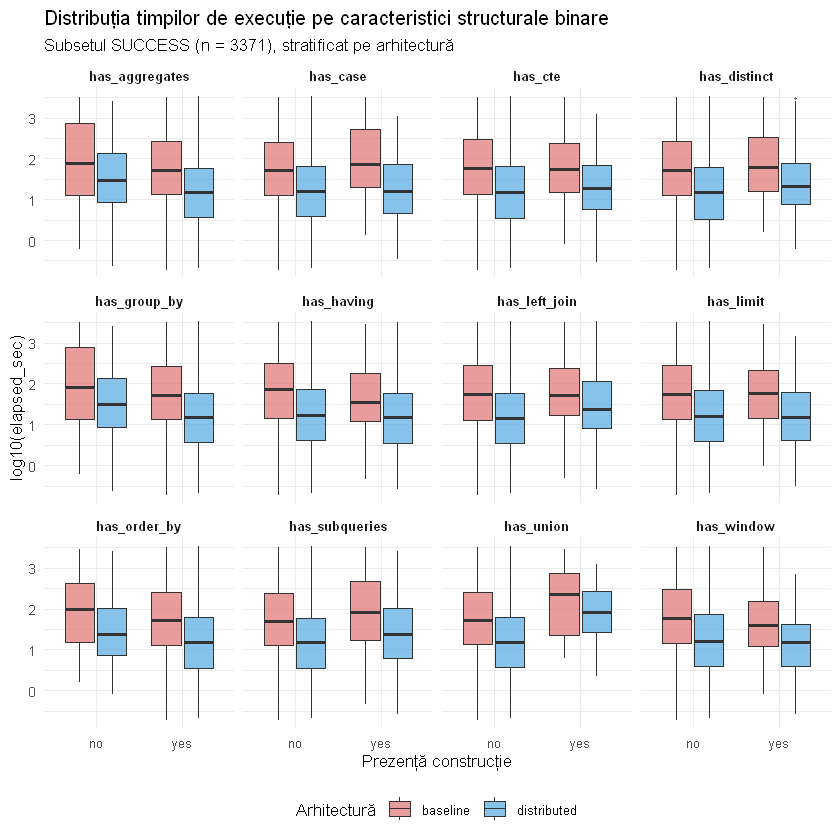

In [40]:
df_long_binary <- df_success %>%
  select(architecture, elapsed_sec, all_of(binary_vars_useful)) %>%
  pivot_longer(
    cols = all_of(binary_vars_useful),
    names_to = "characteristic",
    values_to = "presence"
  )

p_binary_time <- df_long_binary %>%
  ggplot(aes(x = presence, y = log10(elapsed_sec), fill = architecture)) +
  geom_boxplot(alpha = 0.75, outlier.size = 0.4, outlier.alpha = 0.5) +
  facet_wrap(~ characteristic, ncol = 4) +
  scale_fill_manual(values = c("baseline" = "#E07B7B", "distributed" = "#5DADE2")) +
  labs(
    x = "Prezență construcție",
    y = "log10(elapsed_sec)",
    fill = "Arhitectură",
    title = "Distribuția timpilor de execuție pe caracteristici structurale binare",
    subtitle = paste0("Subsetul SUCCESS (n = ", nrow(df_success), "), stratificat pe arhitectură")
  ) +
  theme_minimal(base_size = 10) +
  theme(
    strip.text = element_text(face = "bold"),
    legend.position = "bottom"
  )

p_binary_time

ggsave(
  filename = file.path(figures_dir, "plot_rq4a_binary_characteristics_time.png"),
  plot = p_binary_time,
  width = 13,
  height = 9,
  dpi = 300
)

Graficul compară distribuția timpilor de execuție pentru interogările finalizate cu succes, în funcție de prezența sau absența unor caracteristici structurale SQL, separat pentru arhitectura baseline și cea distribuită.

În aproape toate caracteristicile analizate, distribuția timpilor pentru arhitectura distribuită este poziționată mai jos decât cea pentru baseline. Acest lucru indică faptul că scenariile PostgreSQL/Citus au timpi mai mici decât PostgreSQL mononod atât pentru interogările care conțin aceste construcții SQL, cât și pentru cele care nu le conțin.

Pentru caracteristici frecvente precum `has_aggregates`, `has_group_by` și `has_order_by`, diferența dintre baseline și distributed este vizibilă, ceea ce confirmă că arhitectura distribuită aduce beneficii inclusiv pentru interogări analitice cu agregări, grupări și sortări.

Unele caracteristici par asociate cu timpi mai mari, în special `has_union`, unde atât baseline-ul, cât și arhitectura distribuită au mediane mai ridicate atunci când construcția este prezentă. Un comportament asemănător, dar mai puțin pronunțat, se observă la `has_subqueries`, `has_distinct` și `has_case`.

Pentru alte caracteristici, precum `has_having`, `has_window`, `has_limit` sau `has_left_join`, diferențele dintre prezență și absență sunt mai reduse. Acest lucru sugerează că simpla prezență a construcției nu este suficientă pentru a explica timpul de execuție, fiind necesară analiza împreună cu alți factori, precum numărul de tabele, numărul de join-uri, volumul de date și strategia de distribuire.

În ansamblu, graficul sugerează că arhitectura distribuită reduce timpii de execuție pentru majoritatea categoriilor structurale, însă impactul caracteristicilor SQL nu este uniform. Unele construcții, în special `UNION`, subinterogările și expresiile mai complexe, pot fi asociate cu timpi mai ridicați.

In [46]:
speedup_metadata <- speedup_df %>%
  inner_join(query_metadata, by = "query_id")

df_speedup_binary <- speedup_metadata %>%
  select(scenario, sf, workers, strategy, query_id, speedup, all_of(binary_vars_useful)) %>%
  pivot_longer(
    cols = all_of(binary_vars_useful),
    names_to = "characteristic",
    values_to = "presence"
  )

speedup_binary_summary <- df_speedup_binary %>%
  group_by(characteristic, presence) %>%
  summarise(
    n = n(),
    median_speedup = median(speedup, na.rm = TRUE),
    p25_speedup = quantile(speedup, 0.25, na.rm = TRUE),
    p75_speedup = quantile(speedup, 0.75, na.rm = TRUE),
    pct_faster = mean(speedup > 1, na.rm = TRUE) * 100,
    .groups = "drop"
  ) %>%
  arrange(characteristic, presence)

write_csv(
  speedup_binary_summary,
  file.path(tables_dir, "rq4a_speedup_by_binary_characteristics.csv")
)

speedup_binary_summary

characteristic,presence,n,median_speedup,p25_speedup,p75_speedup,pct_faster
<chr>,<fct>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
has_aggregates,no,244,2.440084,0.5938379,5.475323,63.93443
has_aggregates,yes,2378,3.510594,1.8139991,6.344236,87.00589
has_case,no,2260,3.292788,1.5736062,6.152823,83.58407
has_case,yes,362,3.897179,2.3159995,6.933538,92.81768
has_cte,no,1935,3.480945,1.7613276,6.734219,85.78811
has_cte,yes,687,3.199958,1.3817885,5.466406,82.24163
has_distinct,no,2004,3.759023,1.9668385,6.788056,85.67864
has_distinct,yes,618,2.458758,1.3780213,4.616391,82.20065
has_group_by,no,238,2.352083,0.5782516,5.418078,63.02521


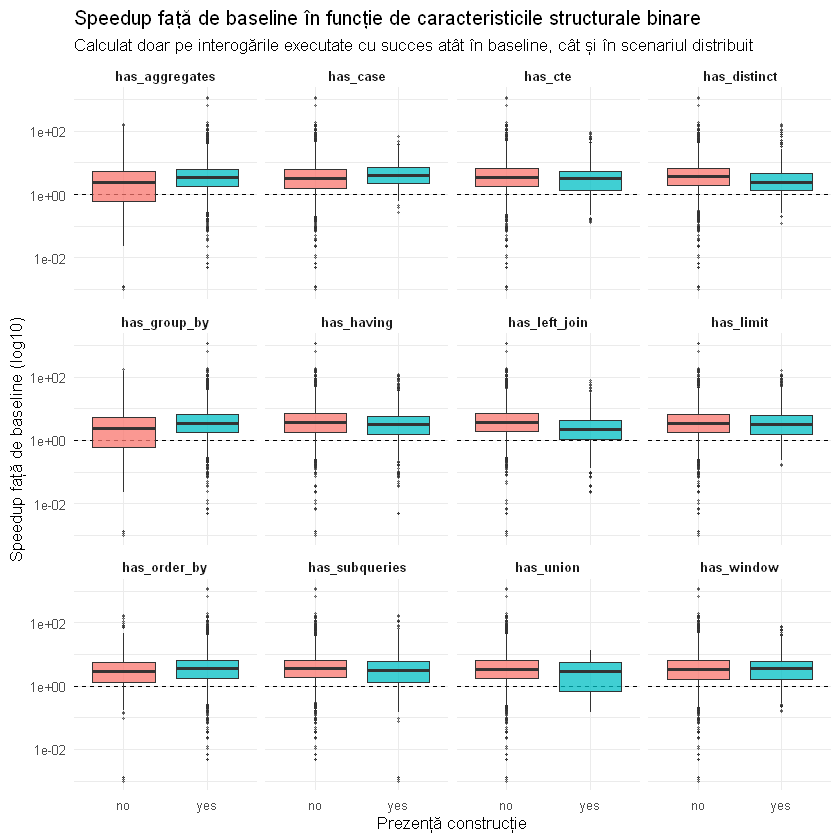

In [47]:
p_speedup_binary <- df_speedup_binary %>%
  ggplot(aes(x = presence, y = speedup, fill = presence)) +
  geom_hline(yintercept = 1, linetype = "dashed") +
  geom_boxplot(alpha = 0.75, outlier.size = 0.4, outlier.alpha = 0.5) +
  facet_wrap(~ characteristic, ncol = 4) +
  scale_y_log10() +
  labs(
    x = "Prezență construcție",
    y = "Speedup față de baseline (log10)",
    title = "Speedup față de baseline în funcție de caracteristicile structurale binare",
    subtitle = "Calculat doar pe interogările executate cu succes atât în baseline, cât și în scenariul distribuit"
  ) +
  theme_minimal(base_size = 10) +
  theme(
    strip.text = element_text(face = "bold"),
    legend.position = "none"
  )

p_speedup_binary

ggsave(
  filename = file.path(figures_dir, "plot_rq4a_speedup_by_binary_characteristics.png"),
  plot = p_speedup_binary,
  width = 13,
  height = 9,
  dpi = 300
)

Graficul arată că, pentru majoritatea caracteristicilor structurale analizate, mediana `speedup` este peste 1, ceea ce indică faptul că scenariile distribuite sunt în general mai rapide decât baseline-ul atât pentru interogările care conțin construcția, cât și pentru cele care nu o conțin.

Diferențele dintre categoriile `no` și `yes` sunt însă moderate. Pentru caracteristici precum `has_aggregates`, `has_group_by`, `has_order_by` și `has_case`, prezența construcției pare asociată cu un speedup ușor mai mare. În schimb, pentru `has_cte`, `has_distinct`, `has_left_join`, `has_subqueries` și `has_union`, prezența construcției pare asociată cu un speedup ceva mai redus sau mai variabil.

Existența multor outlieri arată că beneficiul distribuției nu este uniform la nivel de interogare. Prin urmare, structura query-ului influențează descriptiv nivelul de speedup, dar efectul trebuie analizat împreună cu alte variabile, precum numărul de join-uri, numărul de tabele, scale factor-ul și strategia de distribuire.

### Despre coeficientul Spearman (rho) și p-value

**Spearman `rho`** măsoară puterea și direcția unei relații monotone între două variabile, pe ranguri. Ia valori între −1 și +1:
- Pozitiv: variabilele cresc împreună.
- Negativ: una crește, cealaltă scade.
- 0: nicio relație monotonă.

Spearman nu presupune liniaritate sau normalitate, ceea ce îl face potrivit aici (Shapiro-Wilk a respins normalitatea variabilelor structurale și a timpilor).

Magnitudine `|rho|`: sub 0,10 neglijabilă; 0,10–0,30 slabă; 0,30–0,50 moderată; 0,50–0,70 puternică; peste 0,70 foarte puternică.

**P-value** este probabilitatea de a obține întâmplător o corelație cel puțin la fel de extremă ca cea observată, dacă în populație `rho = 0`. Praguri uzuale: p < 0,001 foarte semnificativ, p < 0,05 semnificativ, p ≥ 0,05 nesemnificativ.

**Citire împreună**: `rho` indică mărimea efectului, p-value indică încrederea că nu este întâmplător. O corelație poate fi semnificativă (p mic) și totuși neglijabilă (rho mic) când eșantionul este mare.

In [50]:
#  Corelații Spearman: variabile numerice × log10(elapsed_sec), per arhitectură

numeric_vars_useful <- c(
  "n_tables", "n_joins", "n_inner_joins", "n_where_predicates",
  "n_aggregate_calls", "n_aggregate_types", "n_having_predicates"
)

spearman_test <- function(x, y) {
  test <- suppressWarnings(cor.test(x, y, method = "spearman", exact = FALSE))
  tibble(
    spearman_rho = round(unname(test$estimate), 3),
    p_value = signif(test$p.value, 3)
  )
}

spearman_summary <- df_success %>%
  select(architecture, elapsed_sec, all_of(numeric_vars_useful)) %>%
  mutate(log_elapsed_sec = log10(elapsed_sec)) %>%
  pivot_longer(
    cols = all_of(numeric_vars_useful),
    names_to = "characteristic",
    values_to = "value"
  ) %>%
  group_by(architecture, characteristic) %>%
  summarise(
    n = n(),
    spearman_test(value, log_elapsed_sec),
    .groups = "drop"
  ) %>%
  pivot_wider(
    names_from = architecture,
    values_from = c(n, spearman_rho, p_value)
  ) %>%
  select(
    characteristic,
    n_baseline, spearman_rho_baseline, p_value_baseline,
    n_distributed, spearman_rho_distributed, p_value_distributed
  )

write_csv(
  spearman_summary,
  file.path(tables_dir, "rq4a_spearman_numeric_characteristics_time.csv")
)

spearman_summary

characteristic,n_baseline,spearman_rho_baseline,p_value_baseline,n_distributed,spearman_rho_distributed,p_value_distributed
<chr>,<int>,<dbl>,<dbl>,<int>,<dbl>,<dbl>
n_aggregate_calls,741,-0.041,0.2620,2630,-0.019,3.32e-01
n_aggregate_types,741,-0.087,0.0178,2630,-0.106,4.82e-08
n_having_predicates,741,-0.085,0.0209,2630,-0.030,1.19e-01
n_inner_joins,741,0.072,0.0501,2630,0.072,2.17e-04
n_joins,741,0.082,0.0250,2630,0.130,1.84e-11
n_tables,741,0.058,0.1150,2630,0.122,3.09e-10
n_where_predicates,741,-0.007,0.8390,2630,0.025,2.03e-01


Corelațiile Spearman sunt foarte slabe în ambele arhitecturi, deoarece valorile coeficientului `rho` sunt apropiate de 0. În baseline, cea mai mare asociere este pentru `n_aggregate_types` (`rho = -0,087`, p = 0,0178) și `n_having_predicates` (`rho = -0,085`, p = 0,0209), iar în distributed cele mai mari valori apar pentru `n_joins` (`rho = 0,130`, p < 0,001) și `n_tables` (`rho = 0,122`, p < 0,001).

Deși unele p-value sunt semnificative statistic, magnitudinea corelațiilor este redusă, deci numărul de tabele, join-uri, agregări sau predicate explică doar slab variația timpului de execuție. Rezultatul sugerează că performanța nu depinde de o singură caracteristică numerică a query-ului, ci de combinația dintre structură, volum de date, strategie de distribuire și arhitectură.

## Caracteristici structurale și executabilitate

În această secțiune sunt analizate toate execuțiile, nu doar cele finalizate cu succes. Scopul este de a observa dacă anumite caracteristici structurale ale interogărilor SQL sunt asociate cu o rată mai mică de succes sau cu anumite tipuri de eșec, în special `CITUS_ARCH_ERROR`.

Spre deosebire de analiza timpilor de execuție, aici sunt relevante toate statusurile, deoarece o interogare care nu se execută cu succes oferă informații importante despre limitele arhitecturii distribuite.

In [51]:
has_vars_all <- names(df_master)[startsWith(names(df_master), "has_")]

execution_by_binary <- df_master %>%
  select(architecture, status, all_of(has_vars_all)) %>%
  pivot_longer(
    cols = all_of(has_vars_all),
    names_to = "characteristic",
    values_to = "presence"
  ) %>%
  group_by(architecture, characteristic, presence) %>%
  summarise(
    n_total = n(),
    n_success = sum(status == "SUCCESS", na.rm = TRUE),
    n_citus_arch_error = sum(status == "CITUS_ARCH_ERROR", na.rm = TRUE),
    n_timeout = sum(status == "TIMEOUT_3600", na.rm = TRUE),
    n_server_crash = sum(status == "SERVER_CRASH", na.rm = TRUE),
    success_rate = round(n_success / n_total * 100, 1),
    citus_arch_error_rate = round(n_citus_arch_error / n_total * 100, 1),
    timeout_rate = round(n_timeout / n_total * 100, 1),
    server_crash_rate = round(n_server_crash / n_total * 100, 1),
    .groups = "drop"
  ) %>%
  arrange(characteristic, architecture, presence)

write_csv(
  execution_by_binary,
  file.path(tables_dir, "rq4b_execution_by_binary_characteristics.csv")
)

execution_by_binary

architecture,characteristic,presence,n_total,n_success,n_citus_arch_error,n_timeout,n_server_crash,success_rate,citus_arch_error_rate,timeout_rate,server_crash_rate
<fct>,<chr>,<fct>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
baseline,has_aggregates,no,81,81,0,0,0,100.0,0.0,0.0,0.0
baseline,has_aggregates,yes,669,660,0,9,0,98.7,0.0,1.3,0.0
distributed,has_aggregates,no,324,244,72,8,0,75.3,22.2,2.5,0.0
distributed,has_aggregates,yes,2676,2386,240,32,18,89.2,9.0,1.2,0.7
baseline,has_case,no,642,637,0,5,0,99.2,0.0,0.8,0.0
baseline,has_case,yes,108,104,0,4,0,96.3,0.0,3.7,0.0
distributed,has_case,no,2568,2268,264,28,8,88.3,10.3,1.1,0.3
distributed,has_case,yes,432,362,48,12,10,83.8,11.1,2.8,2.3
baseline,has_cross_join,no,741,732,0,9,0,98.8,0.0,1.2,0.0


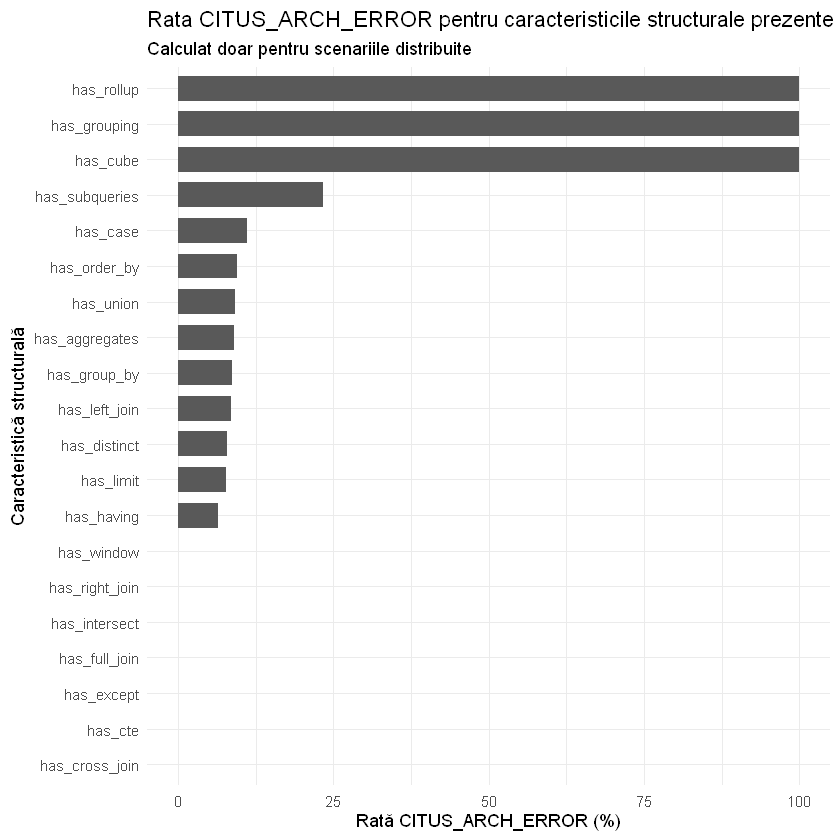

In [52]:
p_citus_error_by_binary <- execution_by_binary %>%
  filter(architecture == "distributed") %>%
  filter(presence == "yes") %>%
  ggplot(aes(x = reorder(characteristic, citus_arch_error_rate),
             y = citus_arch_error_rate)) +
  geom_col(width = 0.7) +
  coord_flip() +
  labs(
    title = "Rata CITUS_ARCH_ERROR pentru caracteristicile structurale prezente",
    subtitle = "Calculat doar pentru scenariile distribuite",
    x = "Caracteristică structurală",
    y = "Rată CITUS_ARCH_ERROR (%)"
  ) +
  theme_minimal(base_size = 11)

p_citus_error_by_binary

ggsave(
  filename = file.path(figures_dir, "plot_rq4b_citus_error_by_binary_characteristics.png"),
  plot = p_citus_error_by_binary,
  width = 10,
  height = 7,
  dpi = 300
)

Graficul arată că `has_rollup`, `has_grouping` și `has_cube` au rată de eroare arhitecturală de 100% în scenariile distribuite.

Dintre caracteristicile mai frecvente, `has_subqueries` are cea mai ridicată rată de `CITUS_ARCH_ERROR`, de aproximativ 23%, ceea ce sugerează că subinterogările pot crea dificultăți suplimentare în execuția distribuită. Alte caracteristici, precum `has_case`, `has_order_by`, `has_union`, `has_aggregates`, `has_group_by`, `has_left_join` și `has_distinct`, au rate mai reduse, aproximativ între 8% și 12%.

Pentru `has_cte`, `has_window`, `has_right_join`, `has_full_join`, `has_cross_join`, `has_except` și `has_intersect`, rata de `CITUS_ARCH_ERROR` este 0% în acest grafic. Acest lucru nu înseamnă neapărat că aceste construcții nu pot fi problematice, ci că, în setul analizat, ele nu sunt asociate direct cu această categorie de eroare.

In [53]:
# Rata de succes pe caracteristici structurale binare ===

success_by_binary <- execution_by_binary %>%
  select(
    architecture, characteristic, presence,
    n_total, n_success, success_rate,
    n_citus_arch_error, citus_arch_error_rate,
    n_timeout, timeout_rate,
    n_server_crash, server_crash_rate
  ) %>%
  arrange(characteristic, architecture, presence)

write_csv(
  success_by_binary,
  file.path(tables_dir, "rq4b_success_rate_by_binary_characteristics.csv")
)

success_by_binary

architecture,characteristic,presence,n_total,n_success,success_rate,n_citus_arch_error,citus_arch_error_rate,n_timeout,timeout_rate,n_server_crash,server_crash_rate
<fct>,<chr>,<fct>,<int>,<int>,<dbl>,<int>,<dbl>,<int>,<dbl>,<int>,<dbl>
baseline,has_aggregates,no,81,81,100.0,0,0.0,0,0.0,0,0.0
baseline,has_aggregates,yes,669,660,98.7,0,0.0,9,1.3,0,0.0
distributed,has_aggregates,no,324,244,75.3,72,22.2,8,2.5,0,0.0
distributed,has_aggregates,yes,2676,2386,89.2,240,9.0,32,1.2,18,0.7
baseline,has_case,no,642,637,99.2,0,0.0,5,0.8,0,0.0
baseline,has_case,yes,108,104,96.3,0,0.0,4,3.7,0,0.0
distributed,has_case,no,2568,2268,88.3,264,10.3,28,1.1,8,0.3
distributed,has_case,yes,432,362,83.8,48,11.1,12,2.8,10,2.3
baseline,has_cross_join,no,741,732,98.8,0,0.0,9,1.2,0,0.0


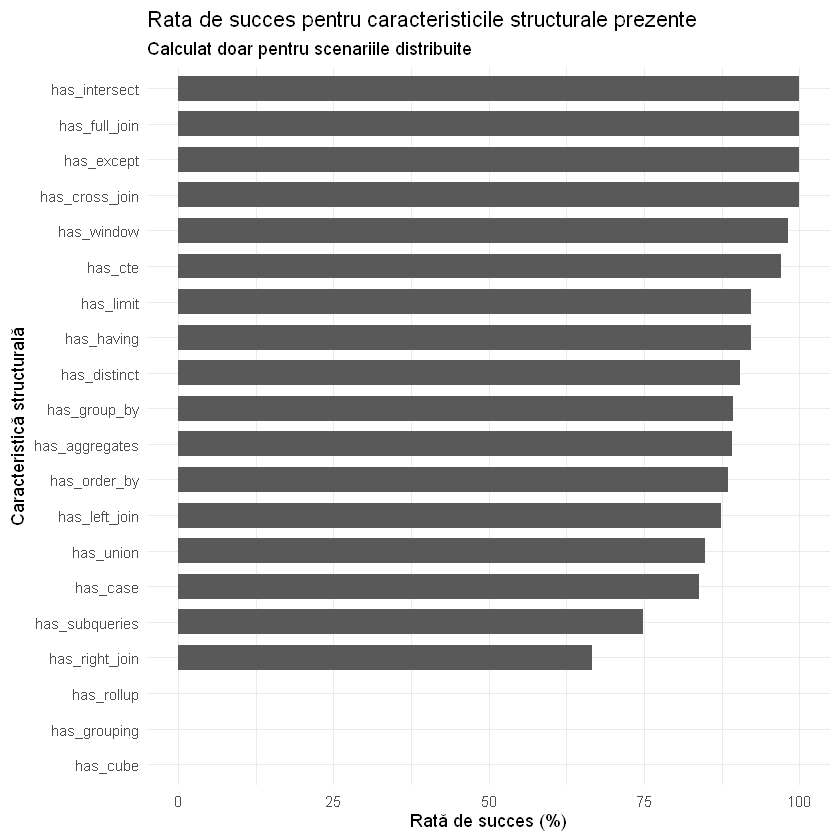

In [54]:
p_success_by_binary_distributed <- success_by_binary %>%
  filter(architecture == "distributed", presence == "yes") %>%
  ggplot(aes(x = reorder(characteristic, success_rate), y = success_rate)) +
  geom_col(width = 0.7) +
  coord_flip() +
  labs(
    title = "Rata de succes pentru caracteristicile structurale prezente",
    subtitle = "Calculat doar pentru scenariile distribuite",
    x = "Caracteristică structurală",
    y = "Rată de succes (%)"
  ) +
  theme_minimal(base_size = 11)

p_success_by_binary_distributed

ggsave(
  filename = file.path(figures_dir, "plot_rq4b_success_rate_by_binary_distributed.png"),
  plot = p_success_by_binary_distributed,
  width = 10,
  height = 7,
  dpi = 300
)

Caracteristicile frecvente, precum `has_group_by`, `has_aggregates` și `has_order_by`, au rate de succes ridicate, în jur de 89%, ceea ce indică faptul că agregările, grupările și sortările sunt în general executabile în scenariile distribuite analizate.

Cele mai problematice apar la `has_subqueries`, cu o rată de succes de aproximativ 75%, și `has_right_join`, cu aproximativ 67%. Pentru `has_rollup`, `has_grouping` și `has_cube`, rata de succes este 0%, deoarece aceste construcții nu sunt executabile în configurația distribuită cu Citus 

## Caracteristici ale interogărilor problematice

In [57]:
problematic_query_summary <- df_master %>%
  filter(architecture == "distributed") %>%
  group_by(query_id) %>%
  summarise(
    n_executions = n(),
    n_success = sum(status == "SUCCESS"),
    n_citus_arch_error = sum(status == "CITUS_ARCH_ERROR"),
    n_timeout = sum(status == "TIMEOUT_3600"),
    n_server_crash = sum(status == "SERVER_CRASH"),
    success_rate = round(n_success / n_executions * 100, 1),
    .groups = "drop"
  ) %>%
  filter(n_success < n_executions) %>%
  arrange(success_rate, desc(n_citus_arch_error), desc(n_server_crash))

write_csv(
  problematic_query_summary,
  file.path(tables_dir, "rq4b_problematic_query_summary.csv")
)

problematic_query_summary

query_id,n_executions,n_success,n_citus_arch_error,n_timeout,n_server_crash,success_rate
<chr>,<int>,<int>,<int>,<int>,<int>,<dbl>
Q013,12,0,12,0,0,0.0
Q051,12,0,12,0,0,0.0
Q065,12,0,12,0,0,0.0
Q069,12,0,12,0,0,0.0
Q103,12,0,12,0,0,0.0
Q110,12,0,12,0,0,0.0
Q119,12,0,12,0,0,0.0
Q121,12,0,12,0,0,0.0
Q124,12,0,12,0,0,0.0


Tabelul identifică 45 de interogări care au avut cel puțin un eșec în scenariile distribuite. Dintre acestea, 20 de interogări au rată de succes 0%, ceea ce indică faptul că nu au rulat cu succes în niciuna dintre cele 12 execuții distribuite analizate.

Un grup distinct este format din 19 interogări care au exclusiv `CITUS_ARCH_ERROR` în toate cele 12 execuții distribuite. Acestea par să fie afectate de limitări arhitecturale stabile ale execuției distribuite, nu de volumul datelor sau de numărul de workeri. Separat, Q101 are tot rată de succes 0%, dar profilul este diferit: 10 cazuri `SERVER_CRASH` și 2 timeout-uri, ceea ce sugerează un comportament critic diferit de erorile arhitecturale Citus.

Restul interogărilor au eșecuri parțiale, cu rate de succes între 33,3% și 91,7%. Unele sunt afectate de `CITUS_ARCH_ERROR` doar în anumite configurații, în timp ce altele eșuează prin timeout sau crash. Prin urmare, interogările problematice nu formează o singură categorie omogenă: există query-uri incompatibile arhitectural, query-uri instabile operațional și query-uri care devin problematice doar în anumite scenarii distribuite.

In [58]:
# === Profil structural pentru interogările problematice ===

problematic_query_profile <- problematic_query_summary %>%
  left_join(query_metadata, by = "query_id")

write_csv(
  problematic_query_profile,
  file.path(tables_dir, "rq4b_problematic_query_profile.csv")
)

problematic_query_profile

query_id,n_executions,n_success,n_citus_arch_error,n_timeout,n_server_crash,success_rate,n_tables,n_joins,n_subqueries,⋯,has_intersect,has_grouping,has_rollup,has_cube,has_cte,has_subqueries,has_left_join,has_right_join,has_full_join,has_cross_join
<chr>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>
Q013,12,0,12,0,0,0.0,4,2,2,⋯,no,no,no,no,no,yes,no,no,no,no
Q051,12,0,12,0,0,0.0,2,3,0,⋯,no,no,no,no,no,no,no,no,no,no
Q065,12,0,12,0,0,0.0,5,3,1,⋯,no,no,no,no,no,yes,no,no,no,no
Q069,12,0,12,0,0,0.0,3,1,1,⋯,no,no,no,no,no,yes,no,no,no,no
Q103,12,0,12,0,0,0.0,4,3,0,⋯,no,no,yes,no,no,no,no,no,no,no
Q110,12,0,12,0,0,0.0,3,4,2,⋯,no,no,no,no,no,yes,no,no,no,no
Q119,12,0,12,0,0,0.0,4,3,0,⋯,no,no,no,no,no,no,no,no,no,no
Q121,12,0,12,0,0,0.0,3,3,1,⋯,no,no,no,no,no,yes,no,no,no,no
Q124,12,0,12,0,0,0.0,3,2,2,⋯,no,no,no,no,no,yes,no,no,no,no


## Sinteză descriptivă utilă pentru RQ4 pentru caracteristicile binare

In [59]:
rq4_binary_synthesis <- execution_by_binary %>%
  filter(
    architecture == "distributed",
    presence == "yes"
  ) %>%
  select(
    characteristic,
    n_total,
    success_rate,
    citus_arch_error_rate,
    timeout_rate,
    server_crash_rate
  ) %>%
  left_join(
    speedup_binary_summary %>%
      filter(presence == "yes") %>%
      select(
        characteristic,
        median_speedup,
        pct_faster
      ),
    by = "characteristic"
  ) %>%
  arrange(desc(citus_arch_error_rate), success_rate)

write_csv(
  rq4_binary_synthesis,
  file.path(tables_dir, "rq4_binary_synthesis.csv")
)

rq4_binary_synthesis

characteristic,n_total,success_rate,citus_arch_error_rate,timeout_rate,server_crash_rate,median_speedup,pct_faster
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
has_cube,12,0.0,100.0,0.0,0.0,NA,NA
has_grouping,12,0.0,100.0,0.0,0.0,NA,NA
has_rollup,24,0.0,100.0,0.0,0.0,NA,NA
has_subqueries,696,74.9,23.3,1.9,0.0,3.112354,80.42226
has_case,432,83.8,11.1,2.8,2.3,3.897179,92.81768
has_order_by,2520,88.6,9.5,1.2,0.7,3.513026,85.49618
has_union,132,84.8,9.1,0.0,6.1,2.921150,67.85714
has_aggregates,2676,89.2,9.0,1.2,0.7,3.510594,87.00589
has_group_by,2676,89.4,8.7,1.2,0.7,3.505713,87.03859


Tabelul sintetizează relația dintre caracteristicile structurale ale interogărilor (stocate în variabilele de tip factor) și comportamentul acestora în scenariile distribuite. Rezultatele arată că nu toate construcțiile SQL afectează executabilitatea în același mod.

Cele mai clare limitări apar pentru `has_cube`, `has_grouping` și `has_rollup`, unde rata de succes este 0%.

Dintre caracteristicile mai frecvente, `has_subqueries` se remarcă prin cea mai redusă rată de succes, 74,9%, și cea mai ridicată rată `CITUS_ARCH_ERROR`, 23,3%. Acest lucru sugerează că subinterogările reprezintă una dintre construcțiile cele mai problematice pentru execuția distribuită în workload-ul analizat.

Caracteristici analitice frecvente, precum `has_aggregates`, `has_group_by` și `has_order_by`, au rate de succes ridicate, între 88,6% și 89,4%, și valori mediane ale speedup-ului de aproximativ 3,5. Acest rezultat indică faptul că interogările cu agregări, grupări și sortări sunt, în general, executabile în Citus și beneficiază de accelerare față de baseline.

Pentru `has_cte` și `has_window`, rata de succes este foarte ridicată, 97,0%, respectiv 98,1%, iar rata `CITUS_ARCH_ERROR` este 0%. Caracteristicile nu sunt asociate direct cu erori arhitecturale în cadrul experimentului, deși pot influența punctual timpul de execuție.

În cazul caracteristicilor foarte rare, precum `has_cross_join`, `has_except`, `has_full_join` și `has_intersect`, rata de succes apare ca 100%, însă numărul de cazuri este redus. Aceste valori indică doar că în execuțiile analizate nu au generat eșecuri.

În ansamblu, analiza caracteristicilor binare arată că executabilitatea în scenariile distribuite este afectată mai ales de anumite construcții SQL specifice. Agregările și grupările uzuale sunt în general gestionate bine, în timp ce construcțiile neacceptate distribuit și subinterogările sunt asociate cu cele mai multe probleme.

In [60]:
rq4_numeric_synthesis <- spearman_summary %>%
  arrange(desc(abs(spearman_rho_distributed)))

write_csv(
  rq4_numeric_synthesis,
  file.path(tables_dir, "rq4_numeric_synthesis.csv")
)

rq4_numeric_synthesis

characteristic,n_baseline,spearman_rho_baseline,p_value_baseline,n_distributed,spearman_rho_distributed,p_value_distributed
<chr>,<int>,<dbl>,<dbl>,<int>,<dbl>,<dbl>
n_joins,741,0.082,0.0250,2630,0.130,1.84e-11
n_tables,741,0.058,0.1150,2630,0.122,3.09e-10
n_aggregate_types,741,-0.087,0.0178,2630,-0.106,4.82e-08
n_inner_joins,741,0.072,0.0501,2630,0.072,2.17e-04
n_having_predicates,741,-0.085,0.0209,2630,-0.030,1.19e-01
n_where_predicates,741,-0.007,0.8390,2630,0.025,2.03e-01
n_aggregate_calls,741,-0.041,0.2620,2630,-0.019,3.32e-01


Sinteza variabilelor numerice arată că relația dintre complexitatea structurală a interogărilor și timpul de execuție este slabă. În scenariile distribuite, cele mai mari corelații apar pentru `n_joins` (`rho = 0,130`, p < 0,001) și `n_tables` (`rho = 0,122`, p < 0,001), ceea ce sugerează o asociere pozitivă, dar redusă: interogările cu mai multe join-uri și mai multe tabele tind să aibă timpi ușor mai mari.

În baseline, corelațiile sunt și mai mici. Cele mai vizibile valori sunt pentru `n_aggregate_types` (`rho = -0,087`, p = 0,0178), `n_having_predicates` (`rho = -0,085`, p = 0,0209) și `n_joins` (`rho = 0,082`, p = 0,0250), dar toate indică asocieri foarte slabe.

Chiar dacă unele valori p sunt semnificative statistic, coeficienții `rho` sunt apropiați de 0, ceea ce înseamnă că efectul este redus. Prin urmare, numărul de tabele, join-uri, predicate sau agregări nu explică singur variația timpilor de execuție. Performanța depinde de o combinație mai largă de factori: arhitectură, scale factor, strategie de distribuire, executabilitate și forma concretă a interogării.